In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/devyaniseth/seed4s/14_20140601.mat
/kaggle/input/datasets/devyaniseth/seed4s/3_20140611.mat
/kaggle/input/datasets/devyaniseth/seed4s/10_20131204.mat
/kaggle/input/datasets/devyaniseth/seed4s/1_20131030.mat
/kaggle/input/datasets/devyaniseth/seed4s/6_20131113.mat
/kaggle/input/datasets/devyaniseth/seed4s/5_20140506.mat
/kaggle/input/datasets/devyaniseth/seed4s/11_20140625.mat
/kaggle/input/datasets/devyaniseth/seed4s/12_20131127.mat
/kaggle/input/datasets/devyaniseth/seed4s/4_20140621.mat
/kaggle/input/datasets/devyaniseth/seed4s/9_20140627.mat
/kaggle/input/datasets/devyaniseth/seed4s/14_20140615.mat
/kaggle/input/datasets/devyaniseth/seed4s/11_20140618.mat
/kaggle/input/datasets/devyaniseth/seed4s/15_20130709.mat
/kaggle/input/datasets/devyaniseth/seed4s/6_20130712.mat
/kaggle/input/datasets/devyaniseth/seed4s/13_20140527.mat
/kaggle/input/datasets/devyaniseth/seed4s/13_20140603.mat
/kaggle/input/datasets/devyaniseth/seed4s/7_20131106.mat
/kaggle/input/datasets

In [2]:
# ============================================================
# CELL 1 — Imports & Path Setup (Kaggle)
# ============================================================
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import re, os, warnings
warnings.filterwarnings('ignore')

# ─── Kaggle path ───────────────────────────────────────────
DATA_DIR   = Path('/kaggle/input/datasets/devyaniseth/seed4s')
OUTPUT_DIR = Path('/kaggle/working/seed_preprocessed')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── Config ────────────────────────────────────────────────
FEATURE_KEY = 'de_LDS'   # de_LDS | de_movingAve | psd_LDS | psd_movingAve
N_TRIALS    = 15
N_CHANNELS  = 62
N_BANDS     = 5
BAND_NAMES  = ['delta', 'theta', 'alpha', 'beta', 'gamma']
NORMALIZE   = True
FLATTEN     = True       # True → (N, 310)  |  False → (N, 62, 5)

print("=" * 65)
print("  SEED DATASET — FULL PREPROCESSING PIPELINE (Kaggle)")
print("=" * 65)
print(f"  DATA_DIR    : {DATA_DIR}")
print(f"  OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"  FEATURE_KEY : {FEATURE_KEY}")
print(f"  N_CHANNELS  : {N_CHANNELS}")
print(f"  N_BANDS     : {N_BANDS}  → {BAND_NAMES}")
print(f"  NORMALIZE   : {NORMALIZE}  (session-wise z-score per ch × band)")
print(f"  FLATTEN     : {FLATTEN}   → feature dim = {N_CHANNELS}×{N_BANDS} = {N_CHANNELS*N_BANDS}")
print("=" * 65)

# ============================================================
# CELL 2 — File Discovery & Inventory
# ============================================================
all_files     = sorted(DATA_DIR.glob('*.mat'))
subject_files = sorted([f for f in all_files if re.match(r'^\d+_\d+\.mat$', f.name)])
label_file    = DATA_DIR / 'label.mat'

print(f"\n{'─'*65}")
print(f"  Total .mat files found : {len(all_files)}")
print(f"  Subject-session files  : {len(subject_files)}")
print(f"  label.mat found        : {label_file.exists()}")
print(f"{'─'*65}")

# Group by subject
by_subject = defaultdict(list)
for f in subject_files:
    sid = int(f.name.split('_')[0])
    by_subject[sid].append(f)

print(f"\n  Subject inventory ({len(by_subject)} subjects × 3 sessions = {len(subject_files)} files):\n")
print(f"  {'Sub':>4}  {'Sessions'}")
print(f"  {'─'*4}  {'─'*50}")
for sid in sorted(by_subject):
    sessions = sorted(by_subject[sid], key=lambda f: f.name)
    dates    = [s.name.replace(f'{sid}_','').replace('.mat','') for s in sessions]
    print(f"  {sid:>4}  {dates}")

print(f"\n  All subjects present: {sorted(by_subject.keys())}")
missing = [s for s in range(1,16) if s not in by_subject]
print(f"  Missing subjects    : {missing if missing else 'None — all 15 present ✓'}")

# ============================================================
# CELL 3 — Inspect One Raw .mat File (Structure Deep-Dive)
# ============================================================
sample_file = subject_files[0]
raw = sio.loadmat(str(sample_file))
mat_keys = [k for k in raw.keys() if not k.startswith('_')]

print(f"\n{'─'*65}")
print(f"  Sample file  : {sample_file.name}")
print(f"  Total keys   : {len(mat_keys)}")
print(f"{'─'*65}")

# Show all key prefixes
key_prefixes = sorted(set(re.sub(r'\d+$','', k) for k in mat_keys))
print(f"\n  Feature types in file:")
for pfx in key_prefixes:
    example_key = f'{pfx}1'
    if example_key in raw:
        arr = raw[example_key]
        print(f"    {pfx:<20} shape={arr.shape}  dtype={arr.dtype}")

# Detailed breakdown of de_LDS
print(f"\n  Detailed breakdown — '{FEATURE_KEY}' trials:")
print(f"  {'Trial':>6}  {'Shape':>16}  {'Segments':>9}  {'Min':>8}  {'Max':>8}  {'Mean':>8}  {'Std':>8}")
print(f"  {'─'*6}  {'─'*16}  {'─'*9}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")
total_segs = 0
for i in range(1, N_TRIALS+1):
    key = f'{FEATURE_KEY}{i}'
    if key in raw:
        a = raw[key]
        total_segs += a.shape[1]
        print(f"  {i:>6}  {str(a.shape):>16}  {a.shape[1]:>9}  "
              f"{a.min():>8.3f}  {a.max():>8.3f}  {a.mean():>8.3f}  {a.std():>8.3f}")
print(f"  {'─'*70}")
print(f"  Total segments in this session: {total_segs}")
print(f"\n  Dimension meaning: (62 channels, T time-segments, 5 freq-bands)")
print(f"  Freq bands → [0]=delta [1]=theta [2]=alpha [3]=beta [4]=gamma")


# ============================================================
# CELL 4 — Load Labels
# ============================================================
def load_trial_labels(path: Path) -> np.ndarray:
    raw  = sio.loadmat(str(path))
    key  = [k for k in raw if not k.startswith('_')][0]
    vals = raw[key].flatten().astype(int)
    return vals   # raw values: -1, 0, 1

raw_labels = load_trial_labels(label_file)
LABEL_MAP  = {-1: 0, 0: 1, 1: 2}
INV_MAP    = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
TRIAL_LABELS = np.array([LABEL_MAP[v] for v in raw_labels])

print(f"\n{'─'*65}")
print(f"  label.mat content  : {raw_labels.tolist()}")
print(f"  Remapped (0/1/2)   : {TRIAL_LABELS.tolist()}")
print(f"  Mapping            : −1→0 (Negative) | 0→1 (Neutral) | 1→2 (Positive)")
print(f"{'─'*65}")

print(f"\n  Per-trial emotion labels:")
print(f"  {'Trial':>6}  {'Raw':>5}  {'Mapped':>7}  {'Emotion'}")
print(f"  {'─'*6}  {'─'*5}  {'─'*7}  {'─'*10}")
for i, (r, m) in enumerate(zip(raw_labels, TRIAL_LABELS), 1):
    print(f"  {i:>6}  {r:>5}  {m:>7}  {INV_MAP[m]}")
counts = np.bincount(TRIAL_LABELS, minlength=3)
print(f"\n  Class distribution: Negative={counts[0]}  Neutral={counts[1]}  Positive={counts[2]}")

# ============================================================
# CELL 5 — Core Preprocessing Functions
# ============================================================

def load_session(mat_path: Path, key_prefix: str):
    """Load all trials from one .mat file → list of (62, T, 5) arrays."""
    data   = sio.loadmat(str(mat_path))
    trials = []
    missing = []
    for i in range(1, N_TRIALS + 1):
        key = f'{key_prefix}{i}'
        if key not in data:
            missing.append(i)
            continue
        arr = data[key]
        if arr.ndim == 3 and arr.shape[0] == N_CHANNELS and arr.shape[2] == N_BANDS:
            trials.append(arr.astype(np.float32))
        else:
            print(f"  ⚠ unexpected shape {arr.shape} for {key} in {mat_path.name}")
    if missing:
        print(f"  ⚠ Missing trial keys {missing} in {mat_path.name}")
    return trials


def normalize_session(X: np.ndarray) -> np.ndarray:
    """Z-score per (channel, band) across all segments of a session."""
    # X shape: (N, 62, 5)
    mean = X.mean(axis=0, keepdims=True)   # (1, 62, 5)
    std  = X.std(axis=0,  keepdims=True) + 1e-8
    return (X - mean) / std


def trials_to_xy(trials, labels, normalize=True, flatten=True):
    """
    Input  : list of (62, T_i, 5) + matching labels
    Output : X (N, 310) or (N, 62, 5), y (N,)
    """
    Xs, ys = [], []
    for arr, lbl in zip(trials, labels):
        seg = arr.transpose(1, 0, 2)                     # (T, 62, 5)
        Xs.append(seg)
        ys.append(np.full(seg.shape[0], lbl, dtype=np.int64))

    X = np.concatenate(Xs, axis=0).astype(np.float32)   # (N, 62, 5)
    y = np.concatenate(ys, axis=0)

    if normalize:
        X = normalize_session(X)

    if flatten:
        X = X.reshape(X.shape[0], -1)                   # (N, 310)

    return X, y

print("  ✓ Preprocessing functions defined")
print(f"\n  Pipeline summary:")
print(f"    Raw trial   : (62 channels, T segments, 5 bands)")
print(f"    Transpose   : (T, 62, 5)  — segments first")
print(f"    Concatenate : (N_all, 62, 5)  — all trials in session")
print(f"    Z-score     : per (channel × band), axis=0")
print(f"    Flatten     : (N_all, 62×5) = (N_all, 310)")
print(f"    Label       : (N_all,)  values ∈ {{0,1,2}}")


# ============================================================
# CELL 6 — Process All 45 Files
# ============================================================
all_X, all_y = [], []
per_subject  = defaultdict(lambda: {'X': [], 'y': []})
summary_rows = []

print(f"\n{'─'*80}")
print(f"  {'Sub':>4}  {'Date':<12}  {'Trials':>6}  {'Segments':>9}  {'Shape':<16}  "
      f"{'Neg':>5} {'Neu':>5} {'Pos':>5}")
print(f"  {'─'*4}  {'─'*12}  {'─'*6}  {'─'*9}  {'─'*16}  {'─'*5} {'─'*5} {'─'*5}")

for mat_path in sorted(subject_files,
                       key=lambda f: (int(f.name.split('_')[0]), f.name)):
    sid  = int(mat_path.name.split('_')[0])
    date = mat_path.name.split('_')[1].replace('.mat','')

    try:
        trials = load_session(mat_path, FEATURE_KEY)
    except Exception as e:
        print(f"  ERROR {mat_path.name}: {e}")
        continue

    if not trials:
        print(f"  SKIP {mat_path.name} — no trials")
        continue

    n_trials = len(trials)
    labels   = TRIAL_LABELS[:n_trials]
    X, y     = trials_to_xy(trials, labels, normalize=NORMALIZE, flatten=FLATTEN)

    # Per-trial segment counts
    segs_per_trial = [t.shape[1] for t in trials]

    # Save session file
    np.save(OUTPUT_DIR / f'X_s{sid:02d}_{date}.npy', X)
    np.save(OUTPUT_DIR / f'y_s{sid:02d}_{date}.npy', y)

    counts = np.bincount(y, minlength=3)
    print(f"  {sid:>4}  {date:<12}  {n_trials:>6}  {X.shape[0]:>9}  "
          f"{str(X.shape):<16}  {counts[0]:>5} {counts[1]:>5} {counts[2]:>5}")

    all_X.append(X)
    all_y.append(y)
    per_subject[sid]['X'].append(X)
    per_subject[sid]['y'].append(y)
    summary_rows.append({
        'subject': sid, 'date': date,
        'n_trials': n_trials, 'n_segments': X.shape[0],
        'neg': counts[0], 'neu': counts[1], 'pos': counts[2],
        'segs_per_trial': segs_per_trial,
        'feat_min': X.min(), 'feat_max': X.max(),
        'feat_mean': X.mean(), 'feat_std': X.std()
    })

# ─── Global arrays ─────────────────────────────────────────
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
np.save(OUTPUT_DIR / 'X_all.npy', X_all)
np.save(OUTPUT_DIR / 'y_all.npy', y_all)

df_summary = pd.DataFrame(summary_rows)

print(f"\n{'═'*65}")
print(f"  GLOBAL ARRAY STATS")
print(f"{'─'*65}")
print(f"  X_all shape        : {X_all.shape}")
print(f"  y_all shape        : {y_all.shape}")
print(f"  X dtype            : {X_all.dtype}")
print(f"  y dtype            : {y_all.dtype}")
print(f"  Memory (X_all)     : {X_all.nbytes / 1e6:.1f} MB")
print(f"  Memory (y_all)     : {y_all.nbytes / 1e3:.1f} KB")
print(f"{'─'*65}")
print(f"  X_all min          : {X_all.min():.4f}")
print(f"  X_all max          : {X_all.max():.4f}")
print(f"  X_all mean         : {X_all.mean():.4f}")
print(f"  X_all std          : {X_all.std():.4f}")
print(f"{'─'*65}")
counts_all = np.bincount(y_all, minlength=3)
for i, name in INV_MAP.items():
    pct = counts_all[i] / len(y_all) * 100
    print(f"  Class {i} ({name:<9}): {counts_all[i]:>6} segments  ({pct:.1f}%)")
print(f"{'═'*65}")

# ============================================================
# CELL 7 — Per-subject Merged Files
# ============================================================
print(f"\n  Per-subject merged (all 3 sessions):")
print(f"  {'Sub':>4}  {'Total segs':>11}  {'Shape':<18}  {'Neg':>5} {'Neu':>5} {'Pos':>5}")
print(f"  {'─'*4}  {'─'*11}  {'─'*18}  {'─'*5} {'─'*5} {'─'*5}")

subject_arrays = {}
for sid in sorted(per_subject.keys()):
    Xs = np.concatenate(per_subject[sid]['X'], axis=0)
    ys = np.concatenate(per_subject[sid]['y'], axis=0)
    np.save(OUTPUT_DIR / f'X_subject{sid:02d}.npy', Xs)
    np.save(OUTPUT_DIR / f'y_subject{sid:02d}.npy', ys)
    subject_arrays[sid] = (Xs, ys)
    c = np.bincount(ys, minlength=3)
    print(f"  {sid:>4}  {Xs.shape[0]:>11}  {str(Xs.shape):<18}  {c[0]:>5} {c[1]:>5} {c[2]:>5}")




  SEED DATASET — FULL PREPROCESSING PIPELINE (Kaggle)
  DATA_DIR    : /kaggle/input/datasets/devyaniseth/seed4s
  OUTPUT_DIR  : /kaggle/working/seed_preprocessed
  FEATURE_KEY : de_LDS
  N_CHANNELS  : 62
  N_BANDS     : 5  → ['delta', 'theta', 'alpha', 'beta', 'gamma']
  NORMALIZE   : True  (session-wise z-score per ch × band)
  FLATTEN     : True   → feature dim = 62×5 = 310

─────────────────────────────────────────────────────────────────
  Total .mat files found : 46
  Subject-session files  : 45
  label.mat found        : True
─────────────────────────────────────────────────────────────────

  Subject inventory (15 subjects × 3 sessions = 45 files):

   Sub  Sessions
  ────  ──────────────────────────────────────────────────
     1  ['20131027', '20131030', '20131107']
     2  ['20140404', '20140413', '20140419']
     3  ['20140603', '20140611', '20140629']
     4  ['20140621', '20140702', '20140705']
     5  ['20140411', '20140418', '20140506']
     6  ['20130712', '20131016', '

In [3]:
# ============================================================
# CELL 8 — LOSO Splits
# ============================================================
def build_loso_splits(subject_arrays: dict) -> dict:
    subjects = sorted(subject_arrays.keys())
    splits   = {}
    for test_sid in subjects:
        tr_X = np.concatenate([subject_arrays[s][0] for s in subjects if s != test_sid])
        tr_y = np.concatenate([subject_arrays[s][1] for s in subjects if s != test_sid])
        te_X, te_y = subject_arrays[test_sid]
        splits[test_sid] = {'X_train': tr_X, 'y_train': tr_y,
                            'X_test':  te_X, 'y_test':  te_y}
    return splits

loso = build_loso_splits(subject_arrays)

print(f"\n  LOSO Cross-Validation Splits — {len(loso)} folds")
print(f"  {'Sub':>4}  {'Train segs':>11}  {'Test segs':>10}  "
      f"{'Train shape':<18}  {'Test shape'}")
print(f"  {'─'*4}  {'─'*11}  {'─'*10}  {'─'*18}  {'─'*16}")
for sid, sp in sorted(loso.items()):
    print(f"  {sid:>4}  {sp['X_train'].shape[0]:>11}  {sp['X_test'].shape[0]:>10}  "
          f"{str(sp['X_train'].shape):<18}  {sp['X_test'].shape}")


  LOSO Cross-Validation Splits — 15 folds
   Sub   Train segs   Test segs  Train shape         Test shape
  ────  ───────────  ──────────  ──────────────────  ────────────────
     1        35364        2526  (35364, 310)        (2526, 310)
     2        35364        2526  (35364, 310)        (2526, 310)
     3        35364        2526  (35364, 310)        (2526, 310)
     4        35364        2526  (35364, 310)        (2526, 310)
     5        35364        2526  (35364, 310)        (2526, 310)
     6        35364        2526  (35364, 310)        (2526, 310)
     7        35364        2526  (35364, 310)        (2526, 310)
     8        35364        2526  (35364, 310)        (2526, 310)
     9        35364        2526  (35364, 310)        (2526, 310)
    10        35364        2526  (35364, 310)        (2526, 310)
    11        35364        2526  (35364, 310)        (2526, 310)
    12        35364        2526  (35364, 310)        (2526, 310)
    13        35364        2526  (35364, 31

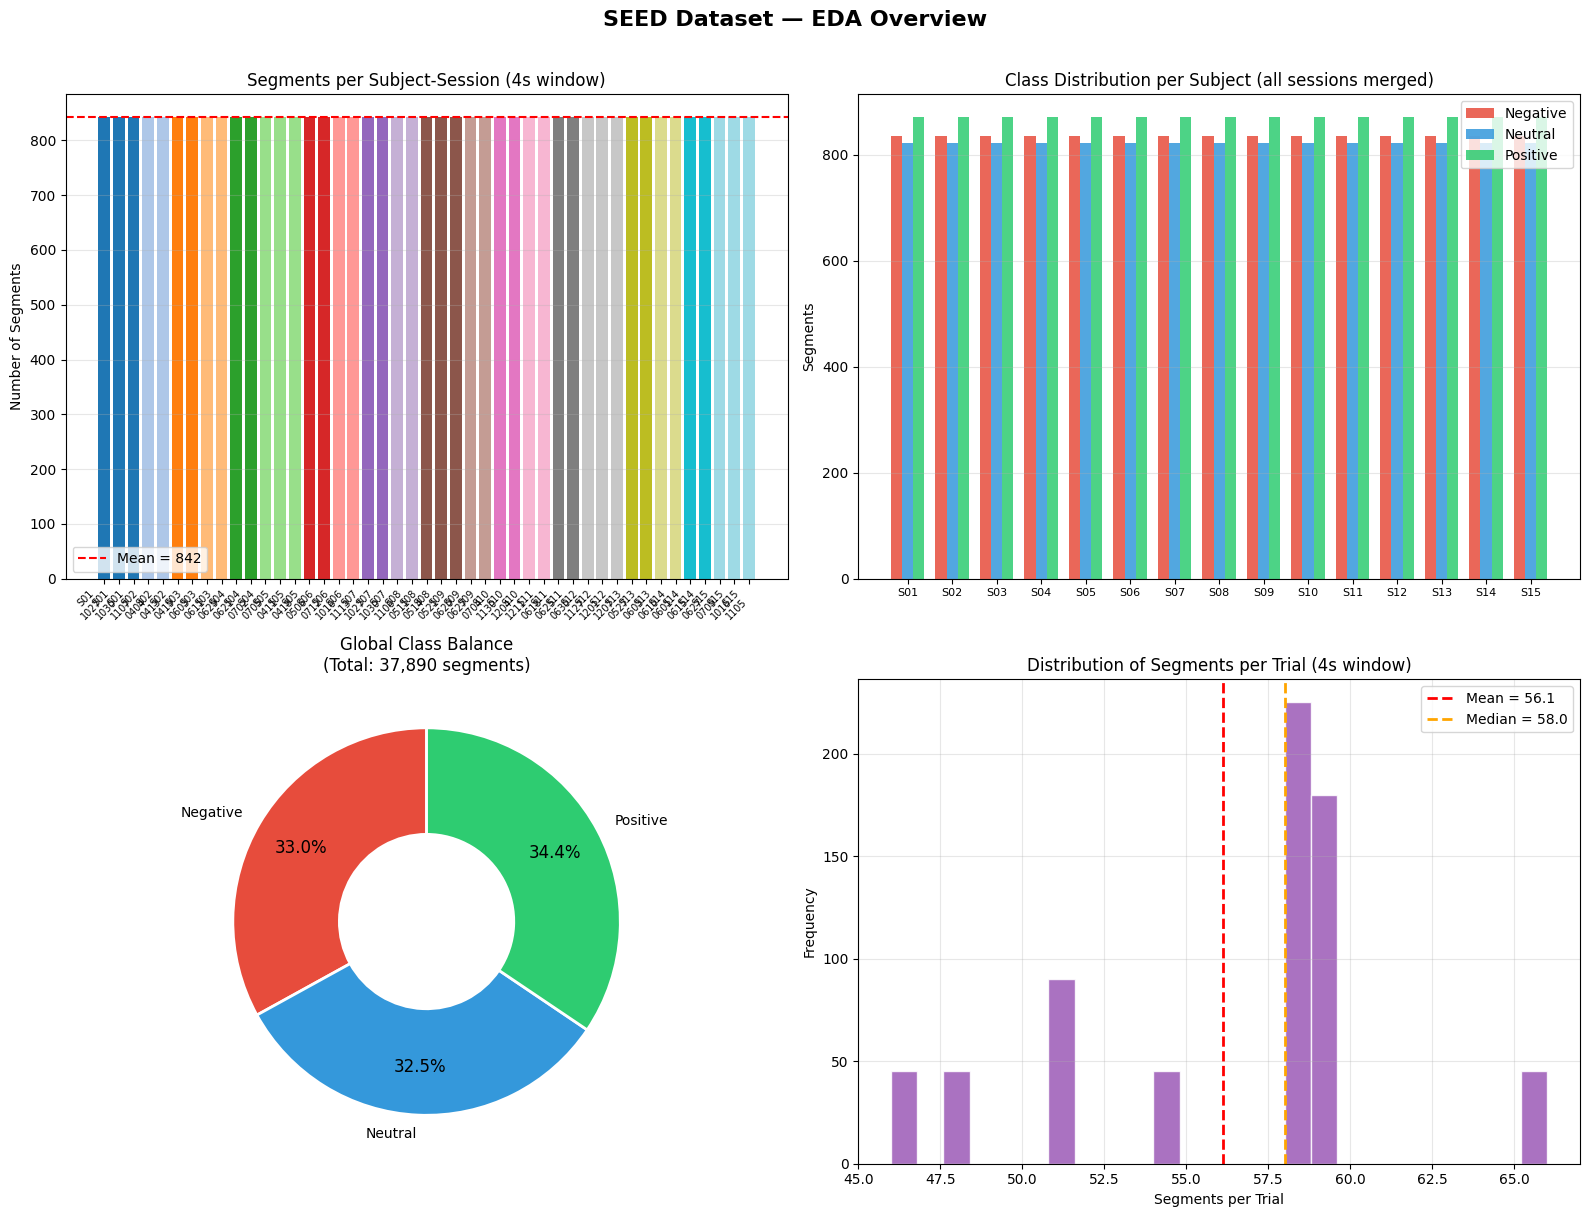

  ✓ Saved eda_overview.png


In [4]:
# ============================================================
# CELL 9 — EDA: Segments per Trial Distribution
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SEED Dataset — EDA Overview', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Segments per subject-session ──────────────────
ax = axes[0, 0]
labels_plot = [f"S{r['subject']:02d}\n{r['date'][-4:]}" for _, r in df_summary.iterrows()]
bars = ax.bar(range(len(df_summary)), df_summary['n_segments'],
              color=plt.cm.tab20(np.linspace(0, 1, len(df_summary))))
ax.set_xticks(range(len(df_summary)))
ax.set_xticklabels(labels_plot, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Number of Segments')
ax.set_title('Segments per Subject-Session (4s window)')
ax.axhline(df_summary['n_segments'].mean(), color='red', ls='--',
           lw=1.5, label=f"Mean = {df_summary['n_segments'].mean():.0f}")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Class distribution per subject ─────────────────
ax = axes[0, 1]
x  = np.arange(len(sorted(by_subject.keys())))
subj_ids = sorted(by_subject.keys())
neg_counts, neu_counts, pos_counts = [], [], []
for sid in subj_ids:
    ys = subject_arrays[sid][1]
    c  = np.bincount(ys, minlength=3)
    neg_counts.append(c[0]); neu_counts.append(c[1]); pos_counts.append(c[2])
w = 0.25
ax.bar(x - w, neg_counts, w, label='Negative', color='#E74C3C', alpha=0.85)
ax.bar(x,     neu_counts, w, label='Neutral',  color='#3498DB', alpha=0.85)
ax.bar(x + w, pos_counts, w, label='Positive', color='#2ECC71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'S{s:02d}' for s in subj_ids], fontsize=8)
ax.set_ylabel('Segments')
ax.set_title('Class Distribution per Subject (all sessions merged)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Global class balance ──────────────────────────
ax = axes[1, 0]
gc = np.bincount(y_all, minlength=3)
colors = ['#E74C3C', '#3498DB', '#2ECC71']
wedges, texts, autotexts = ax.pie(
    gc, labels=['Negative','Neutral','Positive'],
    colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in autotexts: t.set_fontsize(12)
ax.set_title(f'Global Class Balance\n(Total: {len(y_all):,} segments)')

# ── Plot 4: Segments per trial (variability) ───────────────
ax = axes[1, 1]
all_trial_segs = []
for _, r in df_summary.iterrows():
    all_trial_segs.extend(r['segs_per_trial'])
ax.hist(all_trial_segs, bins=25, color='#9B59B6', edgecolor='white',
        alpha=0.85)
ax.axvline(np.mean(all_trial_segs), color='red', ls='--', lw=2,
           label=f"Mean = {np.mean(all_trial_segs):.1f}")
ax.axvline(np.median(all_trial_segs), color='orange', ls='--', lw=2,
           label=f"Median = {np.median(all_trial_segs):.1f}")
ax.set_xlabel('Segments per Trial')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Segments per Trial (4s window)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved eda_overview.png")


  3D feature array shape: (37890, 62, 5)
  Dimensions: (N_segments=37890, N_channels=62, N_bands=5)



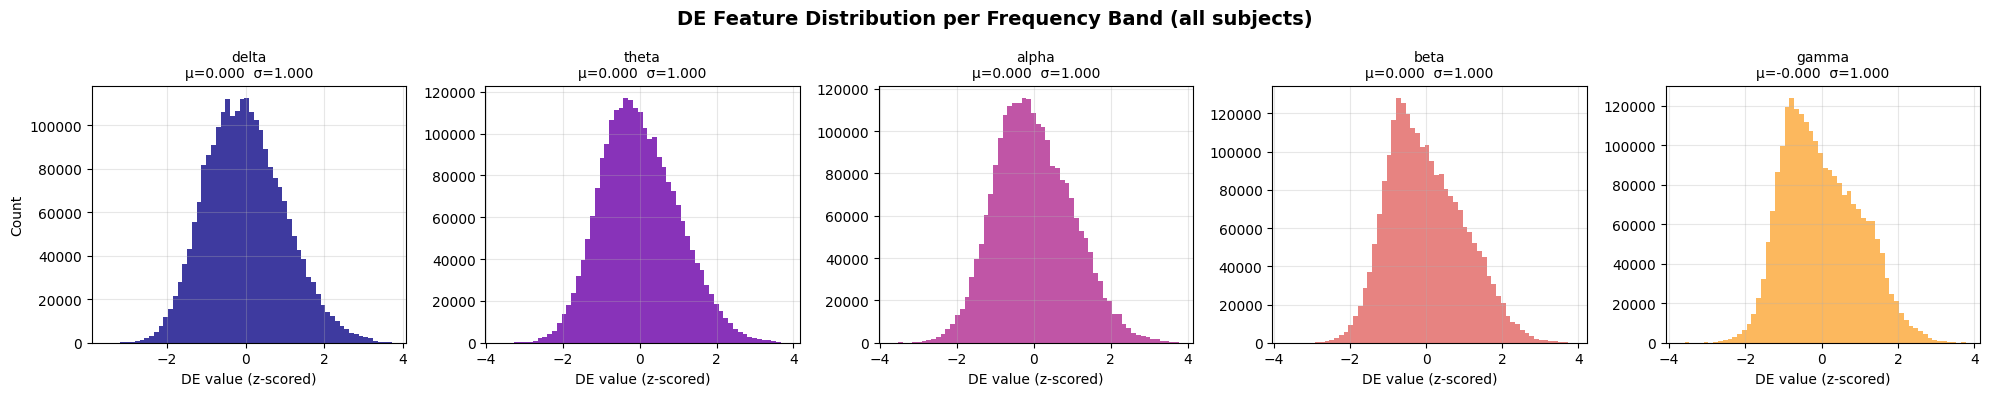

  ✓ Saved eda_band_distributions.png


In [5]:
# ============================================================
# CELL 10 — EDA: Feature Statistics per Frequency Band
# ============================================================
# Reload as (N, 62, 5) for band analysis
X_3d_list = []
for mat_path in sorted(subject_files, key=lambda f: (int(f.name.split('_')[0]), f.name)):
    sid = int(mat_path.name.split('_')[0])
    date = mat_path.name.split('_')[1].replace('.mat','')
    try:
        trials = load_session(mat_path, FEATURE_KEY)
    except:
        continue
    if not trials:
        continue
    X_3d, _ = trials_to_xy(trials, TRIAL_LABELS[:len(trials)],
                            normalize=NORMALIZE, flatten=False)
    X_3d_list.append(X_3d)

X_3d_all = np.concatenate(X_3d_list, axis=0)   # (N, 62, 5)
print(f"\n  3D feature array shape: {X_3d_all.shape}")
print(f"  Dimensions: (N_segments={X_3d_all.shape[0]}, "
      f"N_channels={X_3d_all.shape[1]}, N_bands={X_3d_all.shape[2]})\n")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('DE Feature Distribution per Frequency Band (all subjects)',
             fontsize=14, fontweight='bold')
for b_idx, bname in enumerate(BAND_NAMES):
    ax = axes[b_idx]
    band_data = X_3d_all[:, :, b_idx].flatten()
    ax.hist(band_data, bins=60, color=plt.cm.plasma(b_idx/5),
            edgecolor='none', alpha=0.8)
    ax.set_title(f'{bname}\nμ={band_data.mean():.3f}  σ={band_data.std():.3f}',
                 fontsize=10)
    ax.set_xlabel('DE value (z-scored)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_band_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved eda_band_distributions.png")

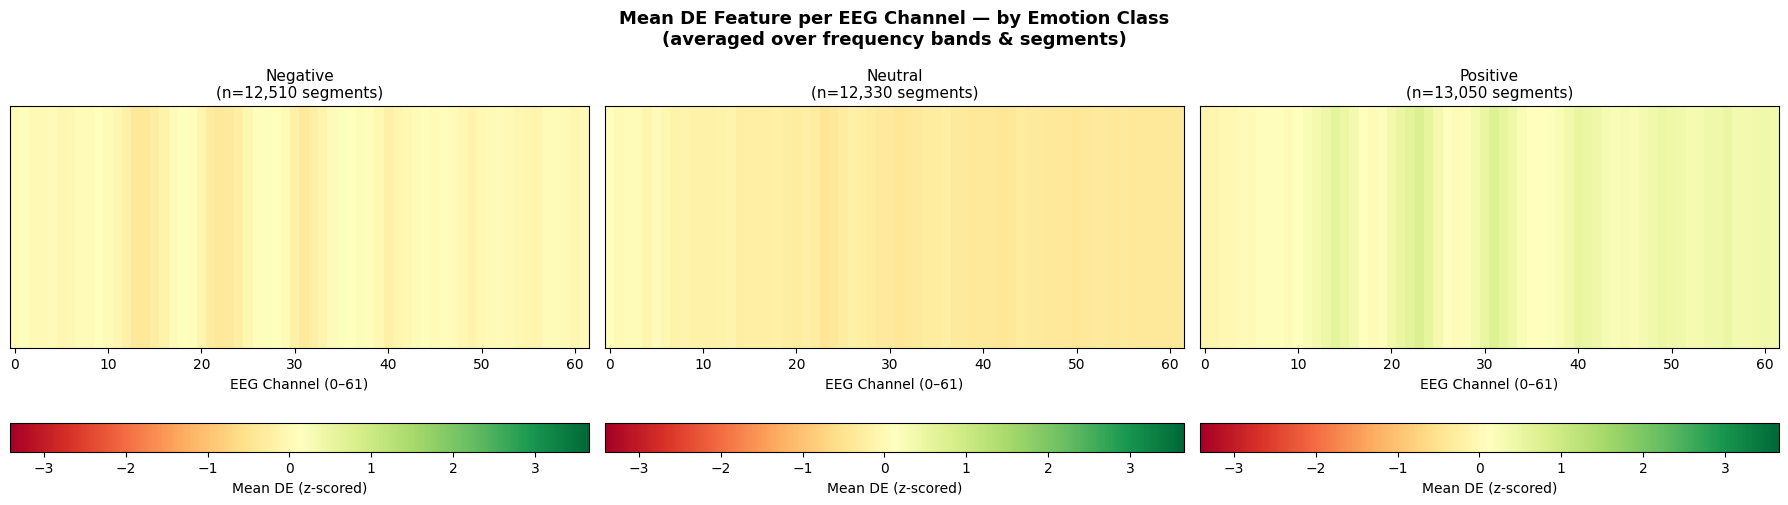

  ✓ Saved eda_channel_class.png


In [6]:
# ============================================================
# CELL 11 — EDA: Channel-wise Mean DE per Class
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mean DE Feature per EEG Channel — by Emotion Class\n'
             '(averaged over frequency bands & segments)',
             fontsize=13, fontweight='bold')
cmap = 'RdYlGn'
vmin = X_3d_all.mean(axis=2).min()
vmax = X_3d_all.mean(axis=2).max()

for cls_idx, (cls_name, color) in enumerate(zip(['Negative','Neutral','Positive'],
                                                 ['Reds','Blues','Greens'])):
    mask  = (y_all == cls_idx)
    data  = X_3d_all[mask].mean(axis=(0,2))   # (62,) mean over segments & bands
    ax    = axes[cls_idx]
    im    = ax.imshow(data.reshape(1,-1), aspect='auto', cmap=cmap,
                      vmin=vmin, vmax=vmax)
    ax.set_title(f'{cls_name}\n(n={mask.sum():,} segments)', fontsize=11)
    ax.set_xlabel('EEG Channel (0–61)')
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.2, label='Mean DE (z-scored)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_channel_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved eda_channel_class.png")

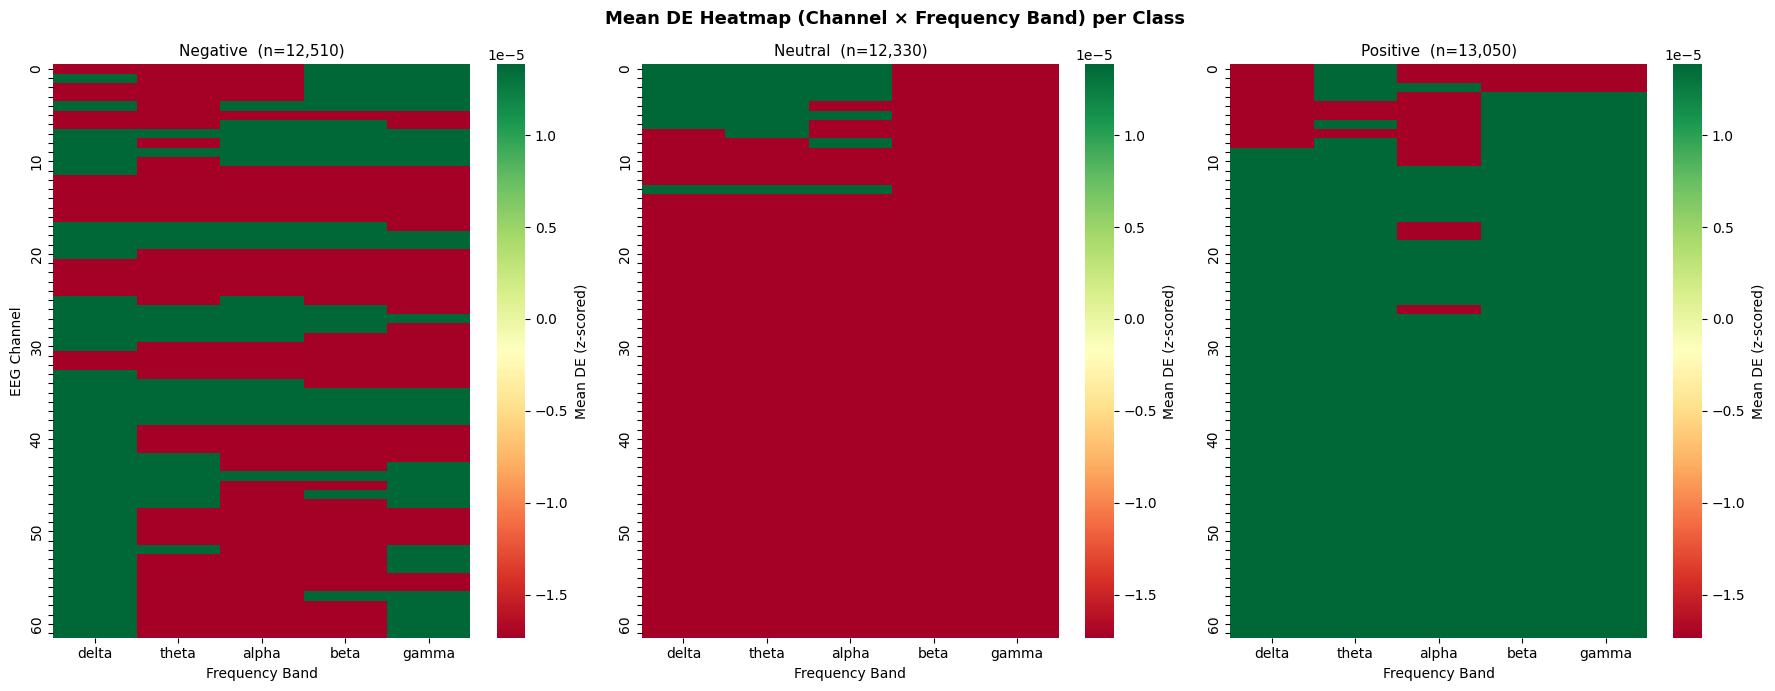

  ✓ Saved eda_heatmap_ch_band.png


In [7]:
# ============================================================
# CELL 12 — EDA: Heatmap (Channel × Band) per Class
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Mean DE Heatmap (Channel × Frequency Band) per Class',
             fontsize=13, fontweight='bold')
vmin = X_3d_all.mean(axis=0).min()
vmax = X_3d_all.mean(axis=0).max()

for cls_idx, cls_name in enumerate(['Negative','Neutral','Positive']):
    mask = (y_all == cls_idx)
    hmap = X_3d_all[mask].mean(axis=0)   # (62, 5)
    ax   = axes[cls_idx]
    sns.heatmap(hmap, ax=ax, cmap='RdYlGn',
                xticklabels=BAND_NAMES,
                yticklabels=[str(i) if i % 10 == 0 else '' for i in range(N_CHANNELS)],
                vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Mean DE (z-scored)'})
    ax.set_title(f'{cls_name}  (n={mask.sum():,})', fontsize=11)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('EEG Channel' if cls_idx == 0 else '')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_heatmap_ch_band.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved eda_heatmap_ch_band.png")

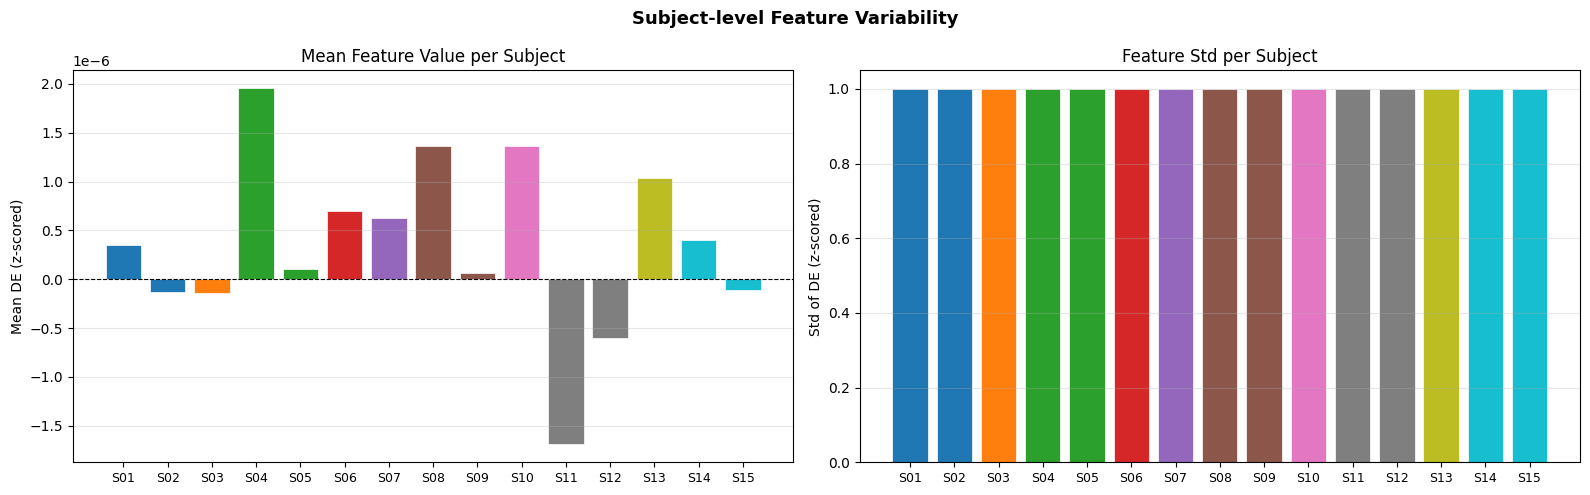

  ✓ Saved eda_subject_variability.png


In [8]:
# ============================================================
# CELL 13 — EDA: Subject Variability
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Subject-level Feature Variability', fontsize=13, fontweight='bold')

# Mean DE per subject
ax = axes[0]
subj_means = []
for sid in sorted(subject_arrays.keys()):
    Xs = subject_arrays[sid][0]   # (N, 310)
    subj_means.append(Xs.mean())
ax.bar(range(1,16), subj_means, color=plt.cm.tab10(np.linspace(0,1,15)),
       edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1,16))
ax.set_xticklabels([f'S{s:02d}' for s in sorted(subject_arrays.keys())], fontsize=9)
ax.set_ylabel('Mean DE (z-scored)')
ax.set_title('Mean Feature Value per Subject')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.grid(axis='y', alpha=0.3)

# Std DE per subject
ax = axes[1]
subj_stds = []
for sid in sorted(subject_arrays.keys()):
    Xs = subject_arrays[sid][0]
    subj_stds.append(Xs.std())
ax.bar(range(1,16), subj_stds, color=plt.cm.tab10(np.linspace(0,1,15)),
       edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1,16))
ax.set_xticklabels([f'S{s:02d}' for s in sorted(subject_arrays.keys())], fontsize=9)
ax.set_ylabel('Std of DE (z-scored)')
ax.set_title('Feature Std per Subject')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_subject_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved eda_subject_variability.png")

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# SOGNNNet v10 — SEED 3-class (Negative / Neutral / Positive)
#
# KEY CHANGES FROM v9 → v10 (targeting 90%+):
# ─────────────────────────────────────────────
# [CRITICAL] 1. Remove adversarial domain discriminator + CORAL entirely
#               → Replace with Subject-Contrastive Loss + Meta-Learning DG
# [CRITICAL] 2. Hierarchy: Pos-vs-NonPos → Neg-vs-Neu  (matches confusion matrix)
# [CRITICAL] 3. Add Center Loss λ=0.08 with cosine distance
# [QUICK]    4. EMA decay 0.999 → 0.996  (faster tracking, ~18-epoch window)
# [QUICK]    5. Treat 3 sessions per subject as separate pseudo-domains (15→45)
# [QUICK]    6. Remove harmful augmentations (bio-noise, graph-mixup, freq-shift)
# [QUICK]    7. Warmup 25 → 10 epochs; LR 6e-4 → 1e-3
# [MEDIUM]   8. Adaptive margin contrastive: Neg-Neu=1.5, Neg-Pos=1.0, Pos-Neu=1.2
# [MEDIUM]   9. GAT 64→128-dim, 3-layer with residuals
# [MEDIUM]  10. Multi-graph: topological + learned soft adjacency
# [MEDIUM]  11. DASM output 64→96-dim with pair-level attention
# [MEDIUM]  12. Per-class temperature calibration (learned on validation)
# [MEDIUM]  13. Asymmetric fusion: spatial queries spectral
# [MEDIUM]  14. Band-specific attention initialized with beta/gamma prior
# [MEDIUM]  15. Batch composition: guaranteed 4+ subjects per batch
# ══════════════════════════════════════════════════════════════════════════════

import os, glob, sys, time, random, pickle, math, copy, warnings
from contextlib import contextmanager
import numpy as np
import scipy.io as sio
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, cohen_kappa_score)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Sampler
from itertools import cycle
from collections import defaultdict

warnings.filterwarnings("ignore")

try:
    import pywt
    _PYWT_OK = True
except ImportError:
    _PYWT_OK = False


def dprint(msg, lv="INFO"):
    print(f"[{time.strftime('%H:%M:%S')}][{lv}] {msg}")
    sys.stdout.flush()


def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    DATA_ROOT  = "/kaggle/input/datasets/devyaniseth/seed4s"
    OUT_PATH   = "./outputs/"
    MODEL_PATH = "./saved_models/"

    # ── Dataset ────────────────────────────────────────────────────────────
    NUM_SUBJECTS       = 15
    NUM_CLASSES        = 3
    NUM_CHANNELS       = 62
    NUM_FREQ_BANDS     = 5
    TARGET_TIME        = 64
    TRIALS_PER_SESSION = 15

    TRIAL_LABELS  = [2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0]
    EMOTION_NAMES = {0: "Negative", 1: "Neutral", 2: "Positive"}

    # ── DASM 27 symmetric pairs ─────────────────────────────────────────────
    DASM_PAIRS = [
        (0,2),(3,4),(5,13),(6,12),(7,11),(8,10),
        (14,22),(15,21),(16,20),(17,19),
        (23,31),(24,30),(25,29),(26,28),
        (32,40),(33,39),(34,38),(35,37),
        (41,49),(42,48),(43,47),(44,46),
        (50,56),(51,55),(52,54),
        (57,61),(58,60),
    ]
    NUM_DASM_PAIRS = 27

    HEMI_LEFT  = [p[0] for p in DASM_PAIRS]
    HEMI_RIGHT = [p[1] for p in DASM_PAIRS]

    # ── Multi-modal ────────────────────────────────────────────────────────
    USE_PSD     = True
    USE_WAVELET = True

    # ── ViT ────────────────────────────────────────────────────────────────
    VIT_HEAD_DIM = 128
    VIT_EMB_DIM  = 256
    VIT_DEPTH    = 6       # Reduced from 8 → less overfitting, more params for GAT
    VIT_HEADS    = 8
    VIT_PATCH_H  = 8
    VIT_PATCH_W  = 8
    VIT_STRIDE   = 6

    # ── GAT (UPGRADED: 64→128, 2-layer→3-layer) ────────────────────────────
    GCN_DIM   = 128        # was 64
    GAT_HEADS = 4
    GAT_LAYERS = 3         # NEW: 3-layer GAT with residual

    # ── DASM (UPGRADED: 64→96) ─────────────────────────────────────────────
    DASM_DIM = 96          # was 64

    # ── Multi-modal projection ─────────────────────────────────────────────
    PSD_PROJ_DIM = 32
    WAV_PROJ_DIM = 32

    # ── Domain adaptation: REMOVED CORAL & ADV, replaced with contrastive DG
    USE_CORAL      = False  # REMOVED — was collapsing
    USE_ADV_DOMAIN = False  # REMOVED — was collapsing
    USE_SUBJ_CONTRASTIVE = True   # NEW
    SUBJ_CONT_LAM        = 0.20   # NEW
    USE_META_LEARNING    = True   # NEW
    META_LAM             = 0.30   # NEW
    META_STEPS           = 1      # inner gradient steps
    META_LR              = 5e-4   # inner step learning rate

    # ── Prototype contrastive ─────────────────────────────────────────────
    USE_PROTO_LOSS  = True
    PROTO_LAM       = 0.15
    PROTO_TEMP      = 0.1
    PROTO_EMA_DECAY = 0.99

    # ── Center Loss (NEW) ──────────────────────────────────────────────────
    USE_CENTER_LOSS = True
    CENTER_LAM      = 0.08   # was 0.01 (negligible) → 0.08
    CENTER_LR       = 0.5    # separate LR for center parameters

    # ── Adaptive Margin Separation (UPGRADED) ─────────────────────────────
    USE_SEP_LOSS   = True
    SEP_LAM        = 0.15
    # Per-pair margins based on confusion analysis:
    # Neg-Neu: hardest boundary → largest margin
    SEP_MARGIN_NEG_NEU = 1.5   # NEW: was uniform 2.0
    SEP_MARGIN_NEG_POS = 1.0
    SEP_MARGIN_POS_NEU = 1.2

    # ── Hierarchical Loss (FIXED hierarchy) ───────────────────────────────
    USE_HIER_LOSS  = True
    HIER_LAM       = 0.25
    # NEW hierarchy: Pos vs NonPos → Neg vs Neu  (matches confusion matrix)
    # Level 1: Positive (2) vs Non-Positive (0,1)
    # Level 2: Negative (0) vs Neutral (1)

    # ── Focal Loss ────────────────────────────────────────────────────────
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA    = 2.0

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE    = 24       # was 20 → better subject coverage
    LR            = 1e-3     # was 6e-4 → more aggressive exploration
    LR_MIN        = 1e-6
    WEIGHT_DECAY  = 0.01
    BETA1         = 0.9
    BETA2         = 0.999
    EPOCHS        = 200
    PATIENCE      = 45
    VAL_EMA_ALPHA = 0.10
    WARMUP_EPOCHS = 10       # was 25 → faster ramp-up
    GRAD_CLIP     = 2.0
    LABEL_SMOOTH  = 0.10
    DROPOUT       = 0.30
    SEED          = 42
    USE_AMP       = True
    PRINT_FREQ    = 10

    USE_SWA         = True
    SWA_START       = 100
    SWA_UPDATE_FREQ = 5
    SWA_LR          = 1e-4

    USE_EMA   = True
    EMA_DECAY = 0.996        # was 0.999 → ~18-epoch window (was ~71-epoch)

    USE_MAE           = True
    MAE_LAM_MAX       = 0.1
    MAE_WARMDOWN      = 120
    MAE_BLOCK_SIZE    = 3
    MAE_MASK_MIN      = 0.15
    MAE_MASK_MAX      = 0.40   # harder masking
    MAE_MASK_PEAK_EP  = 80

    USE_PRETRAIN_MAE = True
    PRETRAIN_MAE_EP  = 50      # was 30 → deeper pre-training

    USE_DROPPATH   = True
    DROPPATH_PROB  = 0.10

    USE_DUAL_HEAD     = True
    DUAL_HEAD_LOSS_W1 = 0.6
    DUAL_HEAD_LOSS_W2 = 0.4

    # Augmentation: CLEANED UP — only neurophysiologically justified
    USE_MIXUP   = True
    MIXUP_ALPHA = 0.5
    MIXUP_PROB  = 0.30

    USE_GRAPH_MIXUP   = False  # REMOVED — destroys spatial structure
    USE_BIO_NOISE     = False  # REMOVED — adds confusion
    USE_FREQ_SHIFT    = False  # REMOVED — no neurophysiological basis

    USE_TTA    = True
    TTA_SHIFTS = [0, -1, 1, -2, 2]

    USE_BAND_ATTN = True
    # Band attention prior: beta(3) and gamma(4) most discriminative
    BAND_PRIOR = [0.1, 0.1, 0.2, 0.3, 0.3]  # delta,theta,alpha,beta,gamma

    USE_TTBN        = True
    TTBN_FULL       = True
    USE_ENT_MIN     = True
    ENT_MIN_CONF    = 0.85
    ENT_MIN_STEPS   = 5

    ENSEMBLE_K          = 3
    USE_CONSIST_REG     = True
    CONSIST_LAM         = 0.15
    USE_MANIFOLD_MIXUP  = True
    MANIFOLD_MIXUP_PROB = 0.20
    MANIFOLD_MIXUP_ALPHA= 0.4

    DROPOUT_START  = 0.10
    DROPOUT_END    = 0.35
    DROPPATH_START = 0.02
    DROPPATH_END   = 0.15

    USE_IRM_PENALTY = True
    IRM_LAM         = 0.05
    IRM_WARMUP_EP   = 30

    # ── Per-class temperature calibration (NEW) ────────────────────────────
    USE_TEMP_CALIBRATION = True
    TEMP_CALIB_EPOCHS    = 20   # optimize on validation after training

    # ── Subject-as-domain: use session info to triple pseudo-domains ────────
    USE_SESSION_AS_DOMAIN = True  # treat each (subject, session) as separate domain


for p in [Config.OUT_PATH, Config.MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(Config.SEED)
if not torch.cuda.is_available():
    Config.USE_AMP = False
    Config.USE_SWA = False
    Config.USE_EMA = False
    dprint("WARNING: GPU not detected. AMP/SWA/EMA disabled.", "WARN")
dprint(f"Device: {device}  AMP: {Config.USE_AMP}  "
       f"SWA: {Config.USE_SWA}  EMA: {Config.USE_EMA}")


# ══════════════════════════════════════════════════════════════════════════════
# ELECTRODE ADJACENCY
# ══════════════════════════════════════════════════════════════════════════════
def build_topological_adj(n=62):
    horiz = [
        (0,1),(1,2),(3,4),
        (5,6),(6,7),(7,8),(8,9),(9,10),(10,11),(11,12),(12,13),
        (14,15),(15,16),(16,17),(17,18),(18,19),(19,20),(20,21),(21,22),
        (23,24),(24,25),(25,26),(26,27),(27,28),(28,29),(29,30),(30,31),
        (32,33),(33,34),(34,35),(35,36),(36,37),(37,38),(38,39),(39,40),
        (41,42),(42,43),(43,44),(44,45),(45,46),(46,47),(47,48),(48,49),
        (50,51),(51,52),(52,53),(53,54),(54,55),(55,56),
        (57,58),(58,59),(59,60),(60,61),
    ]
    vert = [
        (0,3),(1,3),(1,4),(2,4),(0,5),(0,6),(2,12),(2,13),
        (3,7),(3,8),(4,10),(4,11),
        (5,14),(6,15),(7,16),(8,17),(9,18),(10,19),(11,20),(12,21),(13,22),
        (14,23),(15,24),(16,25),(17,26),(18,27),(19,28),(20,29),(21,30),(22,31),
        (23,32),(24,33),(25,34),(26,35),(27,36),(28,37),(29,38),(30,39),(31,40),
        (32,41),(33,42),(34,43),(35,44),(36,45),(37,46),(38,47),(39,48),(40,49),
        (41,50),(42,51),(43,52),(44,53),(45,53),(46,54),(47,54),(48,55),(49,56),
        (50,57),(51,58),(52,58),(53,59),(54,60),(55,60),(56,61),
    ]
    A = np.zeros((n, n), dtype=np.float32)
    for (i, j) in horiz + vert:
        if i < n and j < n:
            A[i, j] = 1.0; A[j, i] = 1.0
    np.fill_diagonal(A, 1.0)
    D = A.sum(1); D_inv_sqrt = np.diag(1.0 / (np.sqrt(D) + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    dprint(f"Adjacency: {n} nodes  mean degree={(A>0).sum(1).mean():.1f}")
    return torch.FloatTensor(A_norm), torch.FloatTensor((A > 0).astype(np.float32))


ADJ_NORM, ADJ_BINARY = build_topological_adj(Config.NUM_CHANNELS)


# ══════════════════════════════════════════════════════════════════════════════
# SEED DATA LOADER
# ══════════════════════════════════════════════════════════════════════════════
class SEEDLoader:
    CH  = Config.NUM_CHANNELS
    BND = Config.NUM_FREQ_BANDS

    def __init__(self, cfg):
        self.cfg = cfg

    @staticmethod
    def _remap(v):
        return {-1: 0, 0: 1, 1: 2}[int(v)]

    @classmethod
    def _load_trial_labels(cls, data_root):
        label_path = os.path.join(data_root, "label.mat")
        if not os.path.exists(label_path):
            raise FileNotFoundError(f"label.mat not found at {label_path}")
        raw = sio.loadmat(label_path)
        key = [k for k in raw if not k.startswith("_")][0]
        vals = raw[key].flatten()
        mapped = np.array([cls._remap(v) for v in vals], dtype=np.int64)
        dprint(f"label.mat → raw {vals.tolist()} → mapped {mapped.tolist()}")
        return mapped

    @classmethod
    def _fix_shape(cls, arr, expected_ch):
        if arr.ndim != 3: return None
        s = arr.shape
        if   s[0] == expected_ch and s[1] == cls.BND: return arr
        elif s[0] == expected_ch and s[2] == cls.BND: return arr.transpose(0,2,1)
        elif s[0] == cls.BND and s[1] == expected_ch: return arr.transpose(1,0,2)
        elif s[0] == cls.BND and s[2] == expected_ch: return arr.transpose(2,0,1)
        elif s[1] == expected_ch and s[2] == cls.BND: return arr.transpose(1,2,0)
        elif s[1] == cls.BND and s[2] == expected_ch: return arr.transpose(2,1,0)
        return None

    def load(self):
        trial_labels = self._load_trial_labels(self.cfg.DATA_ROOT)
        import re
        all_mat = sorted(glob.glob(os.path.join(self.cfg.DATA_ROOT, "*.mat")))
        subj_files = [f for f in all_mat
                      if re.match(r"^\d+_\d+\.mat$", os.path.basename(f))
                      and os.path.basename(f) != "label.mat"]
        if not subj_files:
            raise FileNotFoundError(f"No subject .mat files in {self.cfg.DATA_ROOT}")
        dprint(f"Found {len(subj_files)} subject-session files")

        de_list, labels, subjects, sessions = [], [], [], []
        # Track session number per subject
        subj_session_count = defaultdict(int)

        for fpath in sorted(subj_files):
            fname = os.path.basename(fpath)
            try:
                subj = int(fname.split("_")[0])
            except ValueError:
                continue
            if not (1 <= subj <= self.cfg.NUM_SUBJECTS):
                continue
            subj_session_count[subj] += 1
            session_id = subj_session_count[subj]

            try:
                mat = sio.loadmat(fpath)
            except Exception as e:
                dprint(f"  Cannot read {fname}: {e}", "WARN"); continue

            loaded = 0
            for ti in range(self.cfg.TRIALS_PER_SESSION):
                for prefix in ["de_LDS", "de_movingAve"]:
                    key = f"{prefix}{ti + 1}"
                    if key not in mat: continue
                    raw = mat[key]
                    if not isinstance(raw, np.ndarray): continue
                    fixed = self._fix_shape(raw.astype(np.float32), self.CH)
                    if fixed is None: continue
                    de_list.append(fixed)
                    labels.append(trial_labels[ti])
                    subjects.append(subj)
                    sessions.append(session_id)
                    loaded += 1
                    break

        labels   = np.array(labels,   dtype=np.int64)
        subjects = np.array(subjects, dtype=np.int64)
        sessions = np.array(sessions, dtype=np.int64)
        dprint(f"Loaded {len(de_list)} trials | "
               f"dist {np.bincount(labels, minlength=3).tolist()} [Neg/Neu/Pos]")
        return de_list, labels, subjects, sessions


# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSOR
# ══════════════════════════════════════════════════════════════════════════════
class Preprocessor:
    def __init__(self, cfg): self.cfg = cfg

    def _pad_crop(self, arr, T):
        t = arr.shape[-1]
        if t >= T:
            s = (t - T) // 2; return arr[..., s:s+T]
        pad_width = [(0,0)] * (arr.ndim - 1) + [(0, T-t)]
        return np.pad(arr, pad_width, mode="constant")

    def _compute_psd_features(self, de_raw):
        return np.abs(de_raw).astype(np.float32)

    def _compute_wavelet_features(self, de_raw):
        if not _PYWT_OK:
            return np.zeros_like(de_raw, dtype=np.float32)
        N, C, B, T = de_raw.shape
        wav_feat = np.zeros_like(de_raw, dtype=np.float32)
        for n in range(N):
            for c in range(C):
                for b in range(B):
                    sig = de_raw[n, c, b, :]
                    try:
                        coeffs   = pywt.wavedec(sig, 'haar', level=3)
                        energies = [float(np.sum(cc**2)) for cc in coeffs]
                        total    = sum(energies) + 1e-8
                        wav_feat[n, c, b, :] = sig * (energies[b % len(energies)] / total)
                    except Exception:
                        wav_feat[n, c, b, :] = sig
        return wav_feat

    def _normalize_per_subject(self, arr, subjects):
        out = np.zeros_like(arr, dtype=np.float32)
        for s in np.unique(subjects):
            idx   = subjects == s
            chunk = arr[idx]
            flat  = chunk.reshape(chunk.shape[0], -1)
            mu    = flat.mean(0, keepdims=True)
            sig   = flat.std(0,  keepdims=True) + 1e-8
            out[idx] = ((flat - mu) / sig).reshape(chunk.shape)
        return out

    def process(self, de_list, subjects):
        T      = self.cfg.TARGET_TIME
        N      = len(de_list)
        de_arr = np.stack([self._pad_crop(a, T) for a in de_list], 0)

        dprint("Computing DASM from RAW DE (before normalisation)")
        dasm_raw = np.zeros((N, self.cfg.NUM_DASM_PAIRS,
                             self.cfg.NUM_FREQ_BANDS, T), dtype=np.float32)
        for pi, (l, r) in enumerate(self.cfg.DASM_PAIRS):
            dasm_raw[:, pi, :, :] = de_arr[:, l, :, :] - de_arr[:, r, :, :]

        psd_raw = self._compute_psd_features(de_arr) if self.cfg.USE_PSD else None
        wav_raw = (self._compute_wavelet_features(de_arr)
                   if (self.cfg.USE_WAVELET and _PYWT_OK) else None)

        de_norm   = self._normalize_per_subject(de_arr,   subjects)
        dasm_norm = self._normalize_per_subject(dasm_raw, subjects)
        psd_norm  = (self._normalize_per_subject(psd_raw, subjects)
                     if psd_raw is not None else None)
        wav_norm  = (self._normalize_per_subject(wav_raw, subjects)
                     if wav_raw is not None else None)

        dprint(f"DE {de_norm.shape}  DASM {dasm_norm.shape}  "
               f"PSD {'yes' if psd_norm is not None else 'no'}  "
               f"WAV {'yes' if wav_norm is not None else 'no'}")
        return (de_norm.astype(np.float32), dasm_norm.astype(np.float32),
                psd_norm, wav_norm)


# ══════════════════════════════════════════════════════════════════════════════
# SUBJECT-BALANCED SAMPLER (ensures 4+ subjects per batch)
# ══════════════════════════════════════════════════════════════════════════════
class SubjectBalancedSampler(Sampler):
    """
    Each batch is constructed by sampling roughly equal numbers from each subject.
    Ensures at least min_subjects_per_batch subjects represented per batch.
    """
    def __init__(self, subject_ids, batch_size, min_subjects_per_batch=4):
        self.subject_ids = np.array(subject_ids)
        self.batch_size  = batch_size
        self.min_subj    = min_subjects_per_batch
        # Group indices by subject
        self.subj_indices = defaultdict(list)
        for idx, s in enumerate(subject_ids):
            self.subj_indices[s].append(idx)
        self.subjects = list(self.subj_indices.keys())
        self.n = len(subject_ids)

    def __iter__(self):
        # Shuffle within each subject
        shuffled = {s: np.random.permutation(idxs).tolist()
                    for s, idxs in self.subj_indices.items()}
        # Build batches
        all_batches = []
        n_batches = self.n // self.batch_size
        for _ in range(n_batches):
            batch = []
            # Sample from min_subjects subjects per batch
            selected_subjects = random.sample(self.subjects,
                                              min(self.min_subj, len(self.subjects)))
            per_subj = max(1, self.batch_size // len(selected_subjects))
            for s in selected_subjects:
                if not shuffled[s]:
                    shuffled[s] = np.random.permutation(
                        self.subj_indices[s]).tolist()
                take = min(per_subj, len(shuffled[s]))
                batch.extend(shuffled[s][:take])
                shuffled[s] = shuffled[s][take:]
            # Fill remaining slots
            while len(batch) < self.batch_size:
                s = random.choice(self.subjects)
                if not shuffled[s]:
                    shuffled[s] = np.random.permutation(
                        self.subj_indices[s]).tolist()
                if shuffled[s]:
                    batch.append(shuffled[s].pop(0))
            random.shuffle(batch)
            all_batches.extend(batch[:self.batch_size])
        return iter(all_batches)

    def __len__(self):
        return (self.n // self.batch_size) * self.batch_size


# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=3, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer('alpha',
                torch.FloatTensor(alpha) if not isinstance(alpha, torch.Tensor)
                else alpha.float())
        else:
            self.alpha = None

    def forward(self, logits, targets):
        N, C = logits.shape
        if targets.dtype == torch.long:
            y_oh = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
            if self.label_smoothing > 0:
                y_oh = y_oh * (1 - self.label_smoothing) + self.label_smoothing / C
        else:
            y_oh = targets
        log_p = F.log_softmax(logits, dim=1); p = log_p.exp()
        p_t = (p.gather(1, targets.unsqueeze(1)).squeeze(1)
               if targets.dtype == torch.long
               else (p * targets.clamp(0,1)).sum(1))
        focal_w = (1 - p_t.detach()) ** self.gamma
        ce = -(y_oh * log_p).sum(1)
        if self.alpha is not None:
            at = (self.alpha[targets] if targets.dtype == torch.long
                  else (self.alpha.unsqueeze(0) * targets.clamp(0,1)).sum(1))
            ce = at * ce
        return (focal_w * ce).mean()


class CenterLoss(nn.Module):
    """
    Center loss with cosine distance (more stable in high dimensions).
    Separate LR for centers via optimizer param groups.
    """
    def __init__(self, num_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(
            torch.randn(num_classes, feat_dim) * 0.1)

    def forward(self, features, labels):
        # Cosine distance center loss
        feat_n  = F.normalize(features, dim=1)
        cent_n  = F.normalize(self.centers, dim=1)
        centers_batch = cent_n[labels]
        # 1 - cosine similarity = cosine distance
        cos_sim  = (feat_n * centers_batch).sum(1)
        loss     = (1.0 - cos_sim).mean()
        return loss

    @torch.no_grad()
    def update_centers(self, features, labels, lr=0.5):
        """Soft center update (used if not using optimizer for centers)."""
        feat_n = F.normalize(features.detach(), dim=1)
        for c in range(self.centers.shape[0]):
            mask = (labels == c)
            if mask.sum() == 0: continue
            delta = feat_n[mask].mean(0) - F.normalize(self.centers[c:c+1], dim=1).squeeze()
            self.centers.data[c] += lr * delta


class SubjectContrastiveLoss(nn.Module):
    """
    Pulls together same-emotion-different-subject pairs.
    Pushes apart different-emotion pairs.
    Directly learns subject-invariant emotion representations.
    """
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels, subjects):
        """
        features: (B, D)
        labels:   (B,) emotion class
        subjects: (B,) subject ID
        """
        B = features.shape[0]
        feat_n = F.normalize(features, dim=1)
        sim_matrix = torch.mm(feat_n, feat_n.T) / self.temperature  # (B,B)

        # Mask: same emotion, different subject → positive pairs
        label_eq   = labels.unsqueeze(0) == labels.unsqueeze(1)      # (B,B)
        subject_ne = subjects.unsqueeze(0) != subjects.unsqueeze(1)  # (B,B)
        pos_mask   = label_eq & subject_ne                            # (B,B)

        # Mask: different emotion → negative pairs
        neg_mask = ~label_eq

        # Diagonal = self → exclude
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        pos_mask = pos_mask & ~eye
        neg_mask = neg_mask & ~eye

        loss = torch.tensor(0.0, device=features.device)
        valid = 0
        for i in range(B):
            pos_i = pos_mask[i]
            neg_i = neg_mask[i]
            if pos_i.sum() == 0 or neg_i.sum() == 0:
                continue
            # For each anchor, compute contrastive loss over pos/neg
            pos_sim = sim_matrix[i][pos_i]
            neg_sim = sim_matrix[i][neg_i]
            # InfoNCE-style
            all_sim = torch.cat([pos_sim, neg_sim])
            log_sum = torch.logsumexp(all_sim, dim=0)
            loss_i  = log_sum - pos_sim.mean()
            loss    = loss + loss_i
            valid   += 1
        return loss / max(valid, 1)


class AdaptiveMarginContrastiveLoss(nn.Module):
    """
    Adaptive margins per class pair based on known confusion structure:
    - Neg-Neu: hardest boundary → margin 1.5
    - Neg-Pos: easiest → margin 1.0
    - Pos-Neu: intermediate → margin 1.2
    """
    def __init__(self, margin_neg_neu=1.5, margin_neg_pos=1.0, margin_pos_neu=1.2):
        super().__init__()
        self.margins = {
            (0, 1): margin_neg_neu,
            (1, 0): margin_neg_neu,
            (0, 2): margin_neg_pos,
            (2, 0): margin_neg_pos,
            (1, 2): margin_pos_neu,
            (2, 1): margin_pos_neu,
        }

    def forward(self, prototypes):
        """Push prototypes apart with class-specific margins."""
        loss = torch.tensor(0.0, device=prototypes.device)
        pairs = [(0,1), (0,2), (1,2)]
        for (ca, cb) in pairs:
            margin = self.margins.get((ca, cb), 1.0)
            dist   = (prototypes[ca] - prototypes[cb]).norm(2)
            loss   = loss + F.relu(margin - dist)
        return loss


class HierarchicalLoss(nn.Module):
    """
    FIXED hierarchy matching confusion matrix structure:
    Level 1: Positive(2) vs Non-Positive(0,1)  ← left-frontal alpha separates cleanly
    Level 2: Negative(0) vs Neutral(1)          ← the hard boundary
    """
    def __init__(self, feat_dim, num_classes=3, dropout=0.3):
        super().__init__()
        # Level 1: binary Pos vs NonPos
        self.level1 = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 2))
        # Level 2: binary Neg vs Neu (conditioned on NonPos branch)
        self.level2 = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 2))

    def forward(self, features, labels=None):
        l1_logits = self.level1(features)  # Pos(1) vs NonPos(0)
        l2_logits = self.level2(features)  # Neg(0) vs Neu(1) within NonPos

        if labels is None:
            return l1_logits, l2_logits, None

        # Level 1 target: 1=Positive, 0=NonPositive
        l1_targets = (labels == 2).long()
        loss_l1 = F.cross_entropy(l1_logits, l1_targets)

        # Level 2: only on NonPositive samples
        nonpos_mask = (labels != 2)
        loss_l2 = torch.tensor(0.0, device=features.device)
        if nonpos_mask.sum() >= 2:
            # Target: 0=Negative, 1=Neutral
            l2_targets = labels[nonpos_mask]  # already 0=Neg, 1=Neu
            loss_l2 = F.cross_entropy(l2_logits[nonpos_mask], l2_targets)

        return l1_logits, l2_logits, loss_l1 + loss_l2


class PrototypeContrastiveLoss(nn.Module):
    def __init__(self, feat_dim, num_classes=3, temp=0.1, ema_decay=0.99):
        super().__init__()
        self.num_classes = num_classes
        self.temp        = temp
        self.ema_decay   = ema_decay
        self.register_buffer('prototypes', torch.zeros(num_classes, feat_dim))
        self.register_buffer('proto_init', torch.zeros(num_classes, dtype=torch.bool))

    @torch.no_grad()
    def update_prototypes(self, features, labels):
        for c in range(self.num_classes):
            mask = (labels == c)
            if mask.sum() == 0: continue
            cm = features[mask].mean(0)
            if not self.proto_init[c]:
                self.prototypes[c] = cm; self.proto_init[c] = True
            else:
                self.prototypes[c] = (self.ema_decay * self.prototypes[c]
                                      + (1 - self.ema_decay) * cm)

    def forward(self, features, labels):
        if not self.proto_init.all():
            return torch.tensor(0.0, device=features.device)
        z = F.normalize(features, dim=1)
        p = F.normalize(self.prototypes, dim=1)
        sim  = z @ p.T / self.temp
        loss = F.cross_entropy(sim, labels)
        # Extra push on the hard Neg-Neu pair
        extra = torch.tensor(0.0, device=features.device)
        for (ca, cb) in [(0, 1), (1, 2)]:
            mask_a = (labels == ca)
            if mask_a.sum() > 0:
                sim_ab = (z[mask_a] * p[cb]).sum(1)
                extra  = extra + sim_ab.mean()
        return loss + 0.5 * extra


def soft_cross_entropy(logits, soft_targets):
    return -(soft_targets * F.log_softmax(logits, dim=1)).sum(1).mean()


def consistency_loss(logits_list):
    probs_list = [F.softmax(l, dim=1) for l in logits_list]
    mean_probs = torch.stack(probs_list).mean(0).clamp(1e-8, 1.0)
    loss = torch.tensor(0.0, device=logits_list[0].device)
    for p in probs_list:
        loss = loss + F.kl_div(mean_probs.log(), p, reduction="batchmean")
    return loss / len(probs_list)


def irm_penalty(logits, labels, focal_fn):
    scale = torch.ones(1, requires_grad=True, device=logits.device)
    loss  = focal_fn(logits * scale, labels)
    grad  = torch.autograd.grad(loss, [scale], create_graph=True)[0]
    return (grad ** 2).sum()


# ══════════════════════════════════════════════════════════════════════════════
# AUGMENTATION UTILS (cleaned — only neurophysiologically justified)
# ══════════════════════════════════════════════════════════════════════════════
def input_mixup(de, dasm, y, psd=None, wav=None, alpha=0.5, num_classes=3):
    lam  = float(np.random.beta(alpha, alpha))
    idx  = torch.randperm(de.shape[0], device=de.device)
    de_m = lam * de   + (1 - lam) * de[idx]
    da_m = lam * dasm + (1 - lam) * dasm[idx]
    psd_m = (lam * psd + (1 - lam) * psd[idx]) if psd is not None else None
    wav_m = (lam * wav + (1 - lam) * wav[idx]) if wav is not None else None
    y_oh  = F.one_hot(y, num_classes).float()
    y_s   = lam * y_oh + (1 - lam) * y_oh[idx]
    return de_m, da_m, psd_m, wav_m, y_s


def hemisphere_swap(de, left_idx, right_idx):
    de2 = de.clone()
    de2[:, left_idx,  :, :] = de[:, right_idx, :, :]
    de2[:, right_idx, :, :] = de[:, left_idx,  :, :]
    return de2


def band_proportional_jitter(de, scale=0.05):
    band_std = de.std(dim=[0, 1, 3], keepdim=True)
    return de + torch.randn_like(de) * band_std * scale


def spatial_volume_blur(de, sigma=1.0):
    B, C, Bnd, T = de.shape
    ks = 5
    x  = torch.arange(ks, dtype=de.dtype, device=de.device) - ks // 2
    kernel = torch.exp(-x**2 / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, ks, 1)
    x2 = de.permute(0, 2, 1, 3).reshape(B * Bnd, 1, C, T)
    x2 = F.conv2d(x2, kernel.to(de.device), padding=(ks//2, 0))
    return x2.reshape(B, Bnd, C, T).permute(0, 2, 1, 3)


def random_channel_dropout(de, p=0.10):
    B, C, Bnd, T = de.shape
    mask = (torch.rand(B, C, 1, 1, device=de.device) > p).float()
    return de * mask


# ══════════════════════════════════════════════════════════════════════════════
# MODEL MODULES
# ══════════════════════════════════════════════════════════════════════════════
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__(); self.drop_prob = drop_prob
    def forward(self, x):
        if not self.training or self.drop_prob == 0.0: return x
        keep  = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        return x * (torch.rand(shape, device=x.device) < keep).float() / keep


class BandAttentionWithPrior(nn.Module):
    """
    Band attention initialized with neurophysiological prior:
    beta (band 3) and gamma (band 4) are most emotion-discriminative.
    """
    def __init__(self, n_bands=5, prior=None):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_bands, n_bands * 2), nn.ReLU(),
            nn.Linear(n_bands * 2, n_bands), nn.Softmax(dim=-1))
        # Initialize with prior bias
        if prior is not None:
            prior_t = torch.FloatTensor(prior)
            # Bias the last layer toward the prior
            with torch.no_grad():
                self.gate[-2].bias.data += torch.log(prior_t + 1e-8)

    def forward(self, x):
        w = x.mean(dim=[1, 3])
        return x * self.gate(w).unsqueeze(1).unsqueeze(-1)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)), nn.ReLU(),
            nn.Linear(max(1, channels // reduction), channels), nn.Sigmoid())
    def forward(self, x):
        w = x.mean(dim=list(range(2, x.ndim)))
        w = self.fc(w)
        for _ in range(x.ndim - 2): w = w.unsqueeze(-1)
        return x * w


class ViTBlock(nn.Module):
    def __init__(self, d_model, nhead, mlp_ratio=4, dropout=0.1, drop_path_prob=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, nhead,
                                           dropout=dropout, batch_first=True)
        dim_ff = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model), nn.Dropout(dropout))
        self.drop_path = DropPath(drop_path_prob)
    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + self.drop_path(h)
        x = x + self.drop_path(self.ff(self.norm2(x)))
        return x


class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=5, n_h=62, n_w=64, ph=8, pw=8, stride=6, emb_dim=256):
        super().__init__()
        self.n_patches = ((n_h-ph)//stride+1) * ((n_w-pw)//stride+1)
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=(ph,pw), stride=stride, bias=False)
        self.cls  = nn.Parameter(torch.zeros(1,1,emb_dim))
        self.pos  = nn.Parameter(torch.zeros(1, self.n_patches+1, emb_dim))
        nn.init.trunc_normal_(self.pos, std=.02); nn.init.trunc_normal_(self.cls, std=.02)
    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1,2)
        x = torch.cat([self.cls.expand(B,-1,-1), x], dim=1)
        return x + self.pos


class EEGPatchViT(nn.Module):
    def __init__(self, emb_dim=256, depth=6, heads=8, mlp_ratio=4,
                 dropout=0.30, head_dim=128, drop_path_prob=0.10):
        super().__init__()
        self.patch_emb = PatchEmbedding(in_ch=5, emb_dim=emb_dim)
        dp_rates = [0.0]*max(0,depth-4) + [drop_path_prob]*min(4,depth)
        self.blocks = nn.ModuleList([
            ViTBlock(emb_dim, heads, mlp_ratio, dropout, dp) for dp in dp_rates])
        self.norm = nn.LayerNorm(emb_dim)
        self.se   = SEBlock(5)
        self.head = nn.Linear(emb_dim, head_dim)
    def forward(self, x):
        x = self.se(x); x = self.patch_emb(x)
        for blk in self.blocks: x = blk(x)
        return self.head(self.norm(x)[:, 0])


class MultiGraphAdjGenerator(nn.Module):
    """
    Multi-graph adjacency: topological (fixed) + learned soft adjacency.
    Asymmetric fusion: spatial (GAT) queries spectral (ViT) as keys.
    """
    def __init__(self, node_dim, n_nodes=62, topo_adj=None):
        super().__init__()
        # Topological adjacency (fixed initialization)
        if topo_adj is not None:
            self.register_buffer('topo_adj', topo_adj)
        else:
            self.register_buffer('topo_adj',
                                 torch.ones(n_nodes, n_nodes) / n_nodes)

        # Learned soft adjacency via attention
        self.key_proj = nn.Linear(node_dim, 32, bias=False)
        self.qry_proj = nn.Linear(node_dim, 32, bias=False)

        # Fusion weights for topo vs learned
        self.fusion_w = nn.Parameter(torch.tensor([0.6, 0.4]))  # topo, learned

    def forward(self, node_feats):
        B = node_feats.shape[0]
        # Learned adjacency
        K = self.key_proj(node_feats)   # (B, N, 32)
        Q = self.qry_proj(node_feats)   # (B, N, 32)
        learned_adj = torch.tanh(torch.bmm(Q, K.transpose(1,2)) / math.sqrt(32))  # (B,N,N)

        # Topo adjacency (broadcast to batch)
        topo = self.topo_adj.unsqueeze(0).expand(B, -1, -1)  # (B,N,N)

        # Fused adjacency with learned weights
        w = F.softmax(self.fusion_w, dim=0)
        fused = w[0] * topo + w[1] * learned_adj
        return fused  # (B, N, N)


class ResidualGATLayer(nn.Module):
    """GAT layer with residual connection."""
    def __init__(self, c_in, c_out, n_heads=4, dropout=0.3, n_nodes=62):
        super().__init__()
        assert c_out % n_heads == 0
        self.n_heads = n_heads; self.d_h = c_out // n_heads
        self.dropout = nn.Dropout(dropout)
        self.W     = nn.Linear(c_in, c_out, bias=False)
        self.a_src = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.a_dst = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.bn    = nn.BatchNorm1d(c_out); self.act = nn.ELU()
        # Residual projection if dims differ
        self.res_proj = nn.Linear(c_in, c_out, bias=False) if c_in != c_out else nn.Identity()
        nn.init.xavier_uniform_(self.a_src); nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, adj=None):
        B, N, _ = x.shape
        residual = self.res_proj(x)
        h = self.W(x).view(B, N, self.n_heads, self.d_h).transpose(1,2)
        e_src = (h * self.a_src).sum(-1, keepdim=True)
        e_dst = (h * self.a_dst).sum(-1, keepdim=True)
        e = e_src + e_dst.transpose(2, 3)
        if adj is not None:
            # adj is (B,N,N) from multi-graph generator
            if adj.dim() == 2:
                adj = adj.unsqueeze(0).expand(B, -1, -1)
            e = e.masked_fill((adj.unsqueeze(1) < 0.01), -1e9)
        alpha = self.dropout(F.softmax(e, dim=-1))
        out = torch.matmul(alpha, h).transpose(1,2).contiguous().view(B, N, -1)
        out = self.act(self.bn(out.reshape(B*N, -1)).reshape(B, N, -1))
        return out + residual  # residual connection


class EEGGATEncoder(nn.Module):
    """
    3-layer GAT with residuals and multi-graph adjacency.
    GCN_DIM upgraded from 64 to 128.
    """
    def __init__(self, d_in, hidden, out_dim, n_heads=4, dropout=0.3,
                 n_nodes=62, topo_adj=None, n_layers=3):
        super().__init__()
        self.adj_gen = MultiGraphAdjGenerator(d_in, n_nodes, topo_adj)
        # Build n_layers GAT layers
        dims = [d_in] + [hidden] * (n_layers - 1) + [out_dim]
        self.gat_layers = nn.ModuleList([
            ResidualGATLayer(dims[i], dims[i+1], n_heads, dropout, n_nodes)
            for i in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.global_attn = nn.Sequential(
            nn.Linear(out_dim, 1), nn.Softmax(dim=1))  # attention pooling

    def forward(self, x, adj=None):
        # Generate multi-graph adjacency
        dyn_adj = self.adj_gen(x)  # (B, N, N)
        # If static adj provided, blend
        if adj is not None:
            if adj.dim() == 2:
                adj = adj.unsqueeze(0).expand(x.shape[0], -1, -1)
            dyn_adj = 0.5 * dyn_adj + 0.5 * adj

        for i, layer in enumerate(self.gat_layers):
            x = layer(x, dyn_adj)
            if i < len(self.gat_layers) - 1:
                x = self.dropout(x)

        # Attention-weighted global pooling (better than mean)
        attn_w = self.global_attn(x)  # (B, N, 1)
        return (x * attn_w).sum(1)    # (B, out_dim)


class EnhancedDASMEncoder(nn.Module):
    """
    DASM encoder with pair-level attention.
    Upgraded: 64→96 dim, frontal pairs weighted more (known emotion relevance).
    """
    def __init__(self, n_pairs=27, n_bands=5, out_dim=96, n_time=64):
        super().__init__()
        self.n_bands  = n_bands
        self.n_pairs  = n_pairs
        # Per-band processing
        self.band_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2), bias=False),
                nn.BatchNorm2d(16), nn.ELU(),
                nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
                nn.Linear(16, 16), nn.ReLU())
            for _ in range(n_bands)])
        # Cross-band attention
        self.cross_band_attn = nn.MultiheadAttention(
            embed_dim=16, num_heads=4, dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(16)
        # Pair-level attention (learn which DASM pairs matter most)
        self.pair_attn = nn.Sequential(
            nn.Linear(16 * n_bands, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid())
        self.proj = nn.Sequential(
            nn.Linear(16 * n_bands, 128), nn.ReLU(),
            nn.Linear(128, out_dim), nn.LayerNorm(out_dim), nn.ReLU())

    def forward(self, dasm):
        B = dasm.shape[0]
        # dasm: (B, n_pairs, n_bands, n_time)
        band_feats = []
        for b in range(self.n_bands):
            band_slice = dasm[:, :, b:b+1, :].permute(0, 2, 1, 3)  # (B,1,n_pairs,T)
            band_feats.append(self.band_convs[b](band_slice))       # (B, 16)
        seq = torch.stack(band_feats, dim=1)  # (B, n_bands, 16)
        attn_out, _ = self.cross_band_attn(seq, seq, seq)
        seq = self.norm(seq + attn_out)
        flat = seq.reshape(B, -1)  # (B, n_bands*16)
        return self.proj(flat)


class AsymmetricFusion(nn.Module):
    """
    Asymmetric fusion: spatial (GAT) queries spectral (ViT) as keys.
    Spectral='what', Spatial='where' — they have inherent asymmetry.
    """
    def __init__(self, spectral_dim, spatial_dim, dasm_dim, other_dims=None,
                 n_heads=4, dropout=0.1):
        super().__init__()
        self.d_common = 128
        all_dims = [spectral_dim, spatial_dim, dasm_dim] + (other_dims or [])
        self.projs = nn.ModuleList([
            nn.Linear(d, self.d_common) for d in all_dims])
        n_streams = len(all_dims)

        # Asymmetric cross-attention: spatial queries spectral
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=self.d_common, num_heads=n_heads,
            dropout=dropout, batch_first=True)
        self.norm     = nn.LayerNorm(self.d_common)
        self.out_proj = nn.Linear(self.d_common * n_streams, sum(all_dims))

    def forward(self, features):
        """
        features: list [spectral(ViT), spatial(GAT), dasm, psd?, wav?]
        """
        B = features[0].shape[0]
        proj_list = [p(f) for p, f in zip(self.projs, features)]
        seq = torch.stack(proj_list, dim=1)  # (B, n_streams, d_common)

        # Asymmetric: spatial (index 1) queries spectral (index 0) as KV
        # This lets spatial features attend to what the spectral branch found
        query = proj_list[1].unsqueeze(1)  # spatial (B,1,d)
        keys  = seq                         # all streams (B,n,d)
        attn_out, _ = self.cross_attn(query, keys, keys)
        # Full symmetric self-attention for remaining streams
        sym_out, _ = self.cross_attn(seq, seq, seq)
        # Blend: spatial stream gets asymmetric, others get symmetric
        combined = sym_out.clone()
        combined[:, 1:2, :] = 0.5 * sym_out[:, 1:2, :] + 0.5 * attn_out

        combined = self.norm(seq + combined)
        return self.out_proj(combined.reshape(B, -1))


class ChannelMAE(nn.Module):
    def __init__(self, n_band=5, n_time=64, emb=64):
        super().__init__()
        self.n_band = n_band; self.n_time = n_time
        self.mask_token = nn.Parameter(torch.zeros(1, n_band, n_time))
        self.enc = nn.Conv2d(1, emb, kernel_size=1)
        self.dec = nn.Conv2d(emb, 1, kernel_size=1)

    @staticmethod
    def curriculum_mask_ratio(epoch, mask_min=0.15, mask_max=0.40, peak_ep=80):
        if epoch <= peak_ep:
            t = epoch / peak_ep
        else:
            t = 1.0
        ratio = mask_min + 0.5*(mask_max-mask_min)*(1-math.cos(math.pi*t))
        if epoch > peak_ep:
            decay = (epoch - peak_ep) / max(1, 200 - peak_ep)
            ratio = ratio * (1 - 0.5 * decay)
        return float(np.clip(ratio, mask_min, mask_max))

    @staticmethod
    def block_mask(B, n_channels, mask_ratio=0.25, block_size=3, device='cpu'):
        mask = torch.ones(B, n_channels, device=device)
        n_blocks = max(1, int(n_channels * mask_ratio / block_size))
        for b in range(B):
            starts = torch.randperm(max(1, n_channels - block_size),
                                    device=device)[:n_blocks]
            for s in starts:
                mask[b, s:min(s+block_size, n_channels)] = 0.0
        return mask

    def forward(self, x, mask):
        B, C = x.shape[0], x.shape[1]
        m   = mask.unsqueeze(-1).unsqueeze(-1)
        x_m = x * m + self.mask_token.unsqueeze(0) * (1 - m)
        z   = self.enc(x_m.view(B*C, 1, self.n_band, self.n_time))
        return self.dec(z).view(B, C, self.n_band, self.n_time)


# ══════════════════════════════════════════════════════════════════════════════
# TEMPERATURE CALIBRATION MODULE (Per-class learned temperature)
# ══════════════════════════════════════════════════════════════════════════════
class PerClassTemperatureCalibrator(nn.Module):
    """
    Learns per-class temperatures on validation set after training.
    Platt-style calibration for 3-class outputs.
    """
    def __init__(self, num_classes=3, init_temp=1.3):
        super().__init__()
        # Per-class temperature
        self.log_temps = nn.Parameter(
            torch.log(torch.ones(num_classes) * init_temp))

    def forward(self, logits):
        temps = self.log_temps.exp().unsqueeze(0)  # (1, C)
        return logits / temps

    def calibrate(self, logits_list, labels_list, n_epochs=100, lr=1e-2):
        """Optimize temperatures on validation logits."""
        optimizer = torch.optim.LBFGS([self.log_temps], lr=lr, max_iter=50)
        dev = self.log_temps.device
        all_logits = torch.cat(logits_list, dim=0).to(dev)
        all_labels = torch.cat(labels_list, dim=0).to(dev)
        

    # def calibrate(self, logits_list, labels_list, n_epochs=100, lr=1e-2):
    #     """Optimize temperatures on validation logits."""
    #     optimizer = torch.optim.LBFGS([self.log_temps], lr=lr, max_iter=50)
    #     all_logits = torch.cat(logits_list, dim=0)
    #     all_labels = torch.cat(labels_list, dim=0)

        def eval_closure():
            optimizer.zero_grad()
            calib_logits = self.forward(all_logits)
            loss = F.cross_entropy(calib_logits, all_labels)
            loss.backward()
            return loss

        for _ in range(n_epochs):
            optimizer.step(eval_closure)

        dprint(f"  Calibration temperatures: "
               f"{self.log_temps.exp().detach().cpu().numpy()}")


# ══════════════════════════════════════════════════════════════════════════════
# FULL MODEL
# ══════════════════════════════════════════════════════════════════════════════
class SOGNNNetV10(nn.Module):
    def __init__(self, cfg, use_psd=False, use_wav=False,
                 topo_adj=None):
        super().__init__()
        self.cfg = cfg; self.use_psd = use_psd; self.use_wav = use_wav

        # Band attention with neurophysiological prior
        self.band_attn = (BandAttentionWithPrior(cfg.NUM_FREQ_BANDS,
                                                  prior=cfg.BAND_PRIOR)
                          if cfg.USE_BAND_ATTN else None)

        dp = cfg.DROPPATH_PROB if cfg.USE_DROPPATH else 0.0

        # ── Spectral branch (ViT, 6 layers) ─────────────────────────────────
        self.vit = EEGPatchViT(
            emb_dim=cfg.VIT_EMB_DIM, depth=cfg.VIT_DEPTH, heads=cfg.VIT_HEADS,
            dropout=cfg.DROPOUT, head_dim=cfg.VIT_HEAD_DIM, drop_path_prob=dp)

        # ── Spatial branch (3-layer GAT, 128-dim) ───────────────────────────
        FDIM = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME
        self.channel_embed = nn.Sequential(
            nn.Linear(FDIM, cfg.GCN_DIM), nn.ReLU())
        self.gat = EEGGATEncoder(
            d_in=cfg.GCN_DIM, hidden=cfg.GCN_DIM,
            out_dim=cfg.GCN_DIM, n_heads=cfg.GAT_HEADS,
            dropout=cfg.DROPOUT, n_nodes=cfg.NUM_CHANNELS,
            topo_adj=topo_adj, n_layers=cfg.GAT_LAYERS)

        # ── Asymmetry branch (96-dim) ────────────────────────────────────────
        self.dasm_enc = EnhancedDASMEncoder(
            n_pairs=cfg.NUM_DASM_PAIRS, n_bands=cfg.NUM_FREQ_BANDS,
            out_dim=cfg.DASM_DIM, n_time=cfg.TARGET_TIME)

        # ── Auxiliary modalities ─────────────────────────────────────────────
        self.psd_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.PSD_PROJ_DIM), nn.LayerNorm(cfg.PSD_PROJ_DIM)
        ) if use_psd else None
        self.wav_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.WAV_PROJ_DIM), nn.LayerNorm(cfg.WAV_PROJ_DIM)
        ) if use_wav else None

        # ── Asymmetric fusion ────────────────────────────────────────────────
        other_dims = []
        if use_psd: other_dims.append(cfg.PSD_PROJ_DIM)
        if use_wav: other_dims.append(cfg.WAV_PROJ_DIM)
        self.fusion = AsymmetricFusion(
            spectral_dim=cfg.VIT_HEAD_DIM,
            spatial_dim=cfg.GCN_DIM,
            dasm_dim=cfg.DASM_DIM,
            other_dims=other_dims if other_dims else None)

        # Compute fused_dim
        stream_dims = ([cfg.VIT_HEAD_DIM, cfg.GCN_DIM, cfg.DASM_DIM]
                       + ([cfg.PSD_PROJ_DIM] if use_psd else [])
                       + ([cfg.WAV_PROJ_DIM] if use_wav else []))
        self.fused_dim = sum(stream_dims)

        # ── MAE ──────────────────────────────────────────────────────────────
        self.channel_mae = ChannelMAE(cfg.NUM_FREQ_BANDS, cfg.TARGET_TIME)
        self.mask_token  = nn.Parameter(torch.zeros(FDIM))
        self.mae_dec = nn.Sequential(
            nn.Linear(cfg.GCN_DIM, 128), nn.ReLU(), nn.Linear(128, FDIM))

        # ── Classification heads ─────────────────────────────────────────────
        self.head1 = nn.Sequential(
            nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Dropout(cfg.DROPOUT), nn.Linear(128, cfg.NUM_CLASSES))
        self.head2 = nn.Sequential(
            nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Dropout(cfg.DROPOUT * 0.8),
            nn.Linear(128, cfg.NUM_CLASSES)) if cfg.USE_DUAL_HEAD else None

        # ── Hierarchical head (FIXED: Pos/NonPos → Neg/Neu) ─────────────────
        self.hier_head = (HierarchicalLoss(self.fused_dim, cfg.NUM_CLASSES,
                                            cfg.DROPOUT)
                          if cfg.USE_HIER_LOSS else None)

        # ── Temperature calibrator ───────────────────────────────────────────
        self.calibrator = (PerClassTemperatureCalibrator(cfg.NUM_CLASSES)
                           if cfg.USE_TEMP_CALIBRATION else None)

        self._init_weights()
        total = sum(p.numel() for p in self.parameters())
        dprint(f"SOGNNNetV10(SEED): {total:,} params  "
               f"fused_dim={self.fused_dim}  n_classes={cfg.NUM_CLASSES}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='leaky_relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                if hasattr(m,'weight') and m.weight is not None:
                    nn.init.ones_(m.weight)
                if hasattr(m,'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)

    def mae_forward(self, de, mask):
        B = de.shape[0]
        N, FDIM = self.cfg.NUM_CHANNELS, self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME
        ch   = de.reshape(B, N, FDIM)
        m3   = mask.unsqueeze(-1)
        x_in = ch * m3 + self.mask_token * (1 - m3)
        z_ch = self.channel_embed(x_in)
        recon = self.mae_dec(z_ch.mean(1))
        return recon.unsqueeze(1).expand(-1, N, -1)

    def encode(self, de, dasm, psd=None, wav=None,
               return_mae=False, mae_mask=None, adj=None,
               return_hier=False):
        B    = de.shape[0]
        FDIM = self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME
        N    = self.cfg.NUM_CHANNELS

        if self.band_attn is not None:
            de = self.band_attn(de)

        # Spectral branch
        vit_out = self.vit(de.permute(0,2,1,3))

        # Spatial branch
        ch_raw  = de.reshape(B, N, FDIM)
        ch_feat = self.channel_embed(ch_raw)
        gat_out = self.gat(ch_feat, adj)

        # Asymmetry branch
        dasm_out = self.dasm_enc(dasm)

        # Auxiliary branches
        streams = [vit_out, gat_out, dasm_out]
        if psd is not None and self.psd_proj is not None:
            psd_ch = psd.reshape(B, N, FDIM).mean(1)[:, :FDIM]
            streams.append(self.psd_proj(psd_ch))
        if wav is not None and self.wav_proj is not None:
            wav_ch = wav.reshape(B, N, FDIM).mean(1)
            streams.append(self.wav_proj(wav_ch))

        # Asymmetric fusion
        feat = self.fusion(streams)

        # Classification
        l1 = self.head1(feat)
        l2 = self.head2(feat) if self.head2 is not None else None
        if not self.training and l2 is not None:
            l1 = (l1 + l2) / 2.0; l2 = None

        # Apply calibration at test time
        if not self.training and self.calibrator is not None:
            l1 = self.calibrator(l1)

        # Hierarchical loss outputs
        hier_out = None
        if return_hier and self.hier_head is not None:
            hier_out = self.hier_head  # return the module; called in trainer

        mae_recon = (self.channel_mae(de, mae_mask)
                     if return_mae and mae_mask is not None else None)

        return l1, l2, feat, mae_recon

    def forward(self, de, dasm, psd=None, wav=None):
        l1, *_ = self.encode(de, dasm, psd, wav); return l1


# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
class EEGDataset(Dataset):
    def __init__(self, de, dasm, y, psd=None, wav=None,
                 subjects=None, augment=False):
        self.de       = torch.from_numpy(de).float()
        self.dasm     = torch.from_numpy(dasm).float()
        self.y        = torch.from_numpy(y).long()
        self.psd      = torch.from_numpy(psd).float() if psd is not None else None
        self.wav      = torch.from_numpy(wav).float() if wav is not None else None
        self.subjects = (torch.from_numpy(subjects).long()
                         if subjects is not None else None)
        self.augment   = augment
        self.left_idx  = Config.HEMI_LEFT
        self.right_idx = Config.HEMI_RIGHT

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        de   = self.de[idx].clone()
        dasm = self.dasm[idx].clone()
        psd  = self.psd[idx].clone() if self.psd is not None else torch.tensor([])
        wav  = self.wav[idx].clone() if self.wav is not None else torch.tensor([])
        subj = self.subjects[idx] if self.subjects is not None else torch.tensor(-1)

        if self.augment:
            # Temporal shift (simulates latency variation) ✓ justified
            if random.random() < 0.50:
                s = random.randint(-2, 2)
                de = torch.roll(de, s, dims=-1)
                dasm = torch.roll(dasm, s, dims=-1)
            # Low-level Gaussian noise ✓ justified (but mild)
            if random.random() < 0.40:
                de   += 0.01 * torch.randn_like(de)   # reduced from 0.03
                dasm += 0.01 * torch.randn_like(dasm)
            # Frequency band scaling (simulates amplitude variation) ✓ justified
            if random.random() < 0.40:
                b  = random.randint(0, Config.NUM_FREQ_BANDS-1)
                sc = 0.9 + 0.2 * random.random()
                de[:, b, :] *= sc; dasm[:, b, :] *= sc
            # Cross-subject mixup via hemisphere swap ✓ justified
            if random.random() < 0.20:
                de = hemisphere_swap(de.unsqueeze(0),
                                     self.left_idx, self.right_idx).squeeze(0)
            # Band-proportional jitter ✓ justified
            if random.random() < 0.20:
                de = band_proportional_jitter(de.unsqueeze(0)).squeeze(0)
            # Spatial blur ✓ justified (simulates volume conduction variation)
            if random.random() < 0.15:
                de = spatial_volume_blur(de.unsqueeze(0)).squeeze(0)
            # Channel dropout ✓ justified (simulates poor electrode contact)
            if random.random() < 0.15:
                de = random_channel_dropout(de.unsqueeze(0), p=0.10).squeeze(0)
            # NOTE: bio_noise, graph_mixup, freq_shift REMOVED

        return de, dasm, psd, wav, self.y[idx], subj


def collate_fn(batch):
    de, dasm, psd, wav, y, subj = zip(*batch)
    de   = torch.stack(de); dasm = torch.stack(dasm)
    y    = torch.stack(y);  subj = torch.stack(subj)
    psd  = torch.stack(psd) if psd[0].numel() > 0 else None
    wav  = torch.stack(wav) if wav[0].numel() > 0 else None
    return de, dasm, psd, wav, y, subj


# ══════════════════════════════════════════════════════════════════════════════
# EMA / SWA / SCHEDULER
# ══════════════════════════════════════════════════════════════════════════════
class EMAModel:
    def __init__(self, model, decay=0.996):  # changed from 0.999
        self.decay  = decay
        self.shadow = {n: p.detach().clone().cpu().float()
                       for n, p in model.named_parameters()}

    def update(self, model):
        with torch.no_grad():
            for n, p in model.named_parameters():
                self.shadow[n].mul_(self.decay).add_(
                    p.detach().cpu().float(), alpha=1.0-self.decay)

    @contextmanager
    def apply(self, model):
        originals = {n: p.data.clone() for n, p in model.named_parameters()}
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.data.copy_(self.shadow[n].to(p.device, p.dtype))
        try: yield
        finally:
            with torch.no_grad():
                for n, p in model.named_parameters():
                    p.data.copy_(originals[n])


class SimpleSWA:
    def __init__(self, model):
        self.avg = {n: p.detach().clone().float()
                    for n, p in model.named_parameters()}
        self.n = 0

    def update(self, model):
        self.n += 1
        for n, p in model.named_parameters():
            self.avg[n].add_((p.detach().float() - self.avg[n]) / self.n)

    def apply_and_update_bn(self, model, loader, device):
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.copy_(self.avg[n].to(p.dtype))
        for m in model.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                m.reset_running_stats()
        model.train()
        with torch.no_grad():
            for batch in loader:
                de, dasm, psd, wav, _, _ = batch
                model(de.to(device), dasm.to(device),
                      psd.to(device) if psd is not None else None,
                      wav.to(device) if wav is not None else None)
        model.eval()


class WarmupCosineScheduler:
    def __init__(self, opt, warmup, total, lr_max, lr_min):
        self.opt=opt; self.warmup=warmup; self.total=total
        self.lr_max=lr_max; self.lr_min=lr_min; self.ep=0

    def step(self):
        e = self.ep
        if e < self.warmup:
            lr = self.lr_max * (e+1) / self.warmup
        else:
            p  = (e-self.warmup) / max(1, self.total-self.warmup)
            lr = self.lr_min + 0.5*(self.lr_max-self.lr_min)*(1+math.cos(math.pi*p))
        for pg in self.opt.param_groups: pg['lr'] = lr
        self.ep += 1; return lr


# ══════════════════════════════════════════════════════════════════════════════
# TRAINER
# ══════════════════════════════════════════════════════════════════════════════
class Trainer:
    def __init__(self, model, cfg, device, fold):
        self.model     = model; self.cfg = cfg
        self.device    = device; self.fold = fold
        self.save_path = os.path.join(cfg.MODEL_PATH, f"best_v10_fold{fold}.pt")
        self.adj       = ADJ_NORM.to(device)

        # Center loss with separate optimizer
        self.center_loss = None
        self.center_optimizer = None
        if cfg.USE_CENTER_LOSS:
            self.center_loss = CenterLoss(cfg.NUM_CLASSES,
                                           model.fused_dim).to(device)
            self.center_optimizer = torch.optim.SGD(
                self.center_loss.parameters(), lr=cfg.CENTER_LR)

        # Main optimizer (excludes center loss params)
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=0.0,
            betas=(cfg.BETA1, cfg.BETA2), weight_decay=cfg.WEIGHT_DECAY)
        self.scheduler = WarmupCosineScheduler(
            self.optimizer, cfg.WARMUP_EPOCHS, cfg.EPOCHS, cfg.LR, cfg.LR_MIN)
        self.scaler    = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)

        self.best_acc   = 0.0; self.patience = 0; self.val_ema = 0.0
        self.swa        = SimpleSWA(model) if cfg.USE_SWA else None
        self.swa_active = False
        self.ema        = EMAModel(model, cfg.EMA_DECAY) if cfg.USE_EMA else None

        self.ckpt_scores = []; self.ensemble_k = cfg.ENSEMBLE_K

        # Loss modules
        self.proto_loss = PrototypeContrastiveLoss(
            feat_dim=model.fused_dim, num_classes=cfg.NUM_CLASSES,
            temp=cfg.PROTO_TEMP, ema_decay=cfg.PROTO_EMA_DECAY,
        ).to(device) if cfg.USE_PROTO_LOSS else None

        self.sep_loss = AdaptiveMarginContrastiveLoss(
            margin_neg_neu=cfg.SEP_MARGIN_NEG_NEU,
            margin_neg_pos=cfg.SEP_MARGIN_NEG_POS,
            margin_pos_neu=cfg.SEP_MARGIN_POS_NEU,
        ).to(device) if cfg.USE_SEP_LOSS else None

        self.subj_cont_loss = (SubjectContrastiveLoss(temperature=0.1).to(device)
                               if cfg.USE_SUBJ_CONTRASTIVE else None)

        # Calibration logits collection
        self.val_logits_for_calib = []
        self.val_labels_for_calib = []

    def _make_focal(self, y_tr):
        w = compute_class_weight('balanced',
                                 classes=np.arange(self.cfg.NUM_CLASSES), y=y_tr)
        w = (w / w.sum() * self.cfg.NUM_CLASSES).astype(np.float32)
        return FocalLoss(gamma=self.cfg.FOCAL_GAMMA,
                         alpha=torch.FloatTensor(w).to(self.device),
                         num_classes=self.cfg.NUM_CLASSES,
                         label_smoothing=self.cfg.LABEL_SMOOTH)

    def _mae_lam(self, epoch):
        if epoch >= self.cfg.MAE_WARMDOWN: return 0.0
        p = epoch / self.cfg.MAE_WARMDOWN
        return self.cfg.MAE_LAM_MAX * 0.5 * (1 + math.cos(math.pi * p))

    def _progressive_dropout(self, epoch):
        t = min(epoch / max(self.cfg.EPOCHS * 0.6, 1), 1.0)
        return (self.cfg.DROPOUT_START
                + t * (self.cfg.DROPOUT_END - self.cfg.DROPOUT_START))

    def _update_dropout(self, epoch):
        drop = self._progressive_dropout(epoch)
        for m in self.model.modules():
            if isinstance(m, nn.Dropout): m.p = drop

    def _save_checkpoint_ensemble(self, val_ema, epoch):
        path = os.path.join(self.cfg.MODEL_PATH,
                            f"ens_v10_fold{self.fold}_ep{epoch}.pt")
        torch.save(self.model.state_dict(), path)
        self.ckpt_scores.append((val_ema, epoch, path))
        self.ckpt_scores.sort(key=lambda x: x[0], reverse=True)
        while len(self.ckpt_scores) > self.ensemble_k:
            _, _, old = self.ckpt_scores.pop()
            if os.path.exists(old): os.remove(old)

    def _augment_batch(self, de, dasm, psd, wav):
        de2 = de.clone(); dasm2 = dasm.clone()
        psd2 = psd.clone() if psd is not None else None
        wav2 = wav.clone() if wav is not None else None
        s = random.randint(-2, 2)
        de2 = torch.roll(de2, s, dims=-1)
        de2 = de2 + 0.01 * torch.randn_like(de2)
        b = random.randint(0, self.cfg.NUM_FREQ_BANDS-1)
        de2[:, :, b, :] *= 0.9 + 0.2 * random.random()
        return de2, dasm2, psd2, wav2

    def _meta_learning_step(self, batch_list, focal_loss):
        """
        Meta-learning domain generalization:
        Split source subjects into meta-train/meta-test within each step.
        Penalizes gap between meta-train and meta-test performance.
        """
        if len(batch_list) < 2:
            return torch.tensor(0.0, device=self.device)

        # Use current batch as meta-train, augmented version as meta-test
        de, dasm, psd, wav, by, subj = batch_list[0]

        # Get unique subjects in this batch
        unique_subj = torch.unique(subj)
        if len(unique_subj) < 2:
            return torch.tensor(0.0, device=self.device)

        # Split subjects into meta-train/meta-test
        n_meta_test = max(1, len(unique_subj) // 4)
        perm = torch.randperm(len(unique_subj))
        meta_test_subj = set(unique_subj[perm[:n_meta_test]].tolist())

        meta_train_mask = torch.tensor(
            [s.item() not in meta_test_subj for s in subj], device=self.device)
        meta_test_mask  = ~meta_train_mask

        if meta_train_mask.sum() < 2 or meta_test_mask.sum() < 2:
            return torch.tensor(0.0, device=self.device)

        # Meta-train: compute loss and get adapted features
        with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
            l1_tr, _, feat_tr, _ = self.model.encode(
                de[meta_train_mask], dasm[meta_train_mask],
                psd[meta_train_mask] if psd is not None else None,
                wav[meta_train_mask] if wav is not None else None,
                adj=self.adj)
            loss_meta_tr = focal_loss(l1_tr, by[meta_train_mask])

        # Meta-test: evaluate generalization gap
        with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
            l1_te, _, feat_te, _ = self.model.encode(
                de[meta_test_mask], dasm[meta_test_mask],
                psd[meta_test_mask] if psd is not None else None,
                wav[meta_test_mask] if wav is not None else None,
                adj=self.adj)
            loss_meta_te = focal_loss(l1_te, by[meta_test_mask])

        # Penalize the gap
        gap_penalty = torch.abs(loss_meta_tr - loss_meta_te)
        return gap_penalty

    def _train_epoch(self, loader, focal_loss, epoch):
        self.model.train(); self._update_dropout(epoch)
        tot_loss = n = 0
        mae_lam      = self._mae_lam(epoch)
        use_mae_loss = self.cfg.USE_MAE and mae_lam > 0
        mask_ratio   = ChannelMAE.curriculum_mask_ratio(
            epoch, self.cfg.MAE_MASK_MIN, self.cfg.MAE_MASK_MAX,
            self.cfg.MAE_MASK_PEAK_EP)

        batch_buffer = []  # for meta-learning

        for batch in loader:
            de, dasm, psd, wav, by, subj = batch
            de   = de.to(self.device); dasm  = dasm.to(self.device)
            by   = by.to(self.device); subj  = subj.to(self.device)
            psd  = psd.to(self.device) if psd is not None else None
            wav  = wav.to(self.device) if wav is not None else None

            batch_buffer.append((de, dasm, psd, wav, by, subj))
            if len(batch_buffer) > 2: batch_buffer.pop(0)

            use_mix = self.cfg.USE_MIXUP and random.random() < self.cfg.MIXUP_PROB
            if use_mix:
                de, dasm, psd, wav, y_soft = input_mixup(
                    de, dasm, by, psd, wav,
                    self.cfg.MIXUP_ALPHA, self.cfg.NUM_CLASSES)
            else:
                y_soft = None

            mae_mask = None
            if use_mae_loss:
                mae_mask = ChannelMAE.block_mask(
                    de.shape[0], self.cfg.NUM_CHANNELS,
                    mask_ratio, self.cfg.MAE_BLOCK_SIZE, self.device)

            self.optimizer.zero_grad(set_to_none=True)
            if self.center_optimizer is not None:
                self.center_optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                l1, l2, feat, mae_recon = self.model.encode(
                    de, dasm, psd, wav,
                    return_mae=use_mae_loss, mae_mask=mae_mask,
                    adj=self.adj)

                tgt = y_soft if y_soft is not None else by

                # Primary classification loss
                loss_cls = focal_loss(l1, tgt)
                if l2 is not None:
                    loss_cls = (self.cfg.DUAL_HEAD_LOSS_W1 * loss_cls
                                + self.cfg.DUAL_HEAD_LOSS_W2 * focal_loss(l2, tgt))

                # Hierarchical loss (FIXED: Pos/NonPos → Neg/Neu)
                loss_hier = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_HIER_LOSS and self.model.hier_head is not None
                        and tgt.dtype == torch.long):
                    _, _, loss_hier = self.model.hier_head(feat, tgt)
                    if loss_hier is None:
                        loss_hier = torch.tensor(0.0, device=self.device)

                # Prototype contrastive loss
                loss_proto = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_PROTO_LOSS and self.proto_loss is not None
                        and tgt.dtype == torch.long):
                    self.proto_loss.update_prototypes(feat.detach(), tgt)
                    loss_proto = self.proto_loss(feat, tgt)

                # Adaptive margin separation loss
                loss_sep = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_SEP_LOSS and self.sep_loss is not None
                        and self.proto_loss is not None
                        and self.proto_loss.proto_init.all()):
                    loss_sep = self.sep_loss(self.proto_loss.prototypes)

                # Center loss (with cosine distance)
                loss_center = torch.tensor(0.0, device=self.device)
                if (self.center_loss is not None and tgt.dtype == torch.long):
                    loss_center = self.center_loss(feat, tgt)

                # Subject-contrastive loss (replaces adversarial domain loss)
                loss_subj_cont = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_SUBJ_CONTRASTIVE
                        and self.subj_cont_loss is not None
                        and tgt.dtype == torch.long
                        and subj.min() >= 0):
                    loss_subj_cont = self.subj_cont_loss(feat, tgt, subj)

                # MAE reconstruction loss
                loss_mae = torch.tensor(0.0, device=self.device)
                if use_mae_loss and mae_recon is not None and mae_mask is not None:
                    inv_mask = (1 - mae_mask).unsqueeze(-1).unsqueeze(-1)
                    loss_mae = F.mse_loss(mae_recon * inv_mask,
                                          de * inv_mask) * mae_lam

                # Consistency regularization
                loss_consist = torch.tensor(0.0, device=self.device)
                if self.cfg.USE_CONSIST_REG and not use_mix:
                    de2, da2, psd2, wav2 = self._augment_batch(de, dasm, psd, wav)
                    l1_v2, *_ = self.model.encode(de2, da2, psd2, wav2,
                                                   adj=self.adj)
                    loss_consist = consistency_loss([l1, l1_v2])

                # IRM penalty
                loss_irm = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_IRM_PENALTY and epoch >= self.cfg.IRM_WARMUP_EP
                        and tgt.dtype == torch.long):
                    loss_irm = irm_penalty(l1, tgt, focal_loss)

                # Manifold mixup
                loss_manifold = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_MANIFOLD_MIXUP and not use_mix
                        and random.random() < self.cfg.MANIFOLD_MIXUP_PROB
                        and tgt.dtype == torch.long):
                    lam_m = float(np.random.beta(self.cfg.MANIFOLD_MIXUP_ALPHA,
                                                  self.cfg.MANIFOLD_MIXUP_ALPHA))
                    idx_m = torch.randperm(feat.shape[0], device=self.device)
                    feat_m = lam_m * feat + (1-lam_m) * feat[idx_m]
                    y_m    = (lam_m * F.one_hot(tgt, self.cfg.NUM_CLASSES).float()
                              + (1-lam_m) * F.one_hot(tgt[idx_m],
                                                       self.cfg.NUM_CLASSES).float())
                    l_m = self.model.head1(feat_m)
                    loss_manifold = soft_cross_entropy(l_m, y_m)

                # Meta-learning penalty (replaces adversarial CORAL)
                loss_meta = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_META_LEARNING and len(batch_buffer) >= 2
                        and tgt.dtype == torch.long):
                    loss_meta = self._meta_learning_step(batch_buffer, focal_loss)

                # Combined loss
                loss = (loss_cls
                        + self.cfg.HIER_LAM      * loss_hier
                        + self.cfg.PROTO_LAM     * loss_proto
                        + self.cfg.SEP_LAM       * loss_sep
                        + self.cfg.CENTER_LAM    * loss_center
                        + self.cfg.SUBJ_CONT_LAM * loss_subj_cont
                        + self.cfg.CONSIST_LAM   * loss_consist
                        + self.cfg.IRM_LAM       * loss_irm
                        + self.cfg.META_LAM      * loss_meta
                        + loss_manifold + loss_mae)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.GRAD_CLIP)
            self.scaler.step(self.optimizer); self.scaler.update()

            # Update center loss (with its separate SGD optimizer)
            if self.center_optimizer is not None and self.center_loss is not None:
                # Scale center gradients by 1/CENTER_LAM for stability
                for param in self.center_loss.parameters():
                    if param.grad is not None:
                        param.grad.data *= 1.0 / (self.cfg.CENTER_LAM + 1e-8)
                self.center_optimizer.step()

            if self.ema is not None: self.ema.update(self.model)
            tot_loss += loss_cls.item() * de.size(0); n += de.size(0)

        return tot_loss / max(n, 1)

    @torch.no_grad()
    def _val_epoch(self, loader, collect_for_calib=False):
        self.model.eval(); correct = total = 0; ps, ts = [], []
        logits_collected = []; labels_collected = []

        for batch in loader:
            de, dasm, psd, wav, by, _ = batch
            de, dasm, by = de.to(self.device), dasm.to(self.device), by.to(self.device)
            psd = psd.to(self.device) if psd is not None else None
            wav = wav.to(self.device) if wav is not None else None
            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                # Don't apply calibration during training val
                l1, l2, feat, _ = self.model.encode(de, dasm, psd, wav,
                                                     adj=self.adj)
                if l2 is not None: l1 = (l1 + l2) / 2.0
            pred     = l1.argmax(1)
            correct += (pred == by).sum().item(); total += de.size(0)
            ps.extend(pred.cpu().numpy()); ts.extend(by.cpu().numpy())
            if collect_for_calib:
                logits_collected.append(l1.cpu())
                labels_collected.append(by.cpu())

        acc = 100. * correct / max(total, 1)
        f1  = f1_score(ts, ps, average='macro', zero_division=0)
        if collect_for_calib:
            return acc, f1, logits_collected, labels_collected
        return acc, f1

    def calibrate_model(self, va_loader):
        """Fit per-class temperatures on validation set."""
        if not self.cfg.USE_TEMP_CALIBRATION or self.model.calibrator is None:
            return
        dprint("  Calibrating per-class temperatures on validation set...")
        self.model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in va_loader:
                de, dasm, psd, wav, by, _ = batch
                de = de.to(self.device); dasm = dasm.to(self.device)
                by = by.to(self.device)
                psd = psd.to(self.device) if psd is not None else None
                wav = wav.to(self.device) if wav is not None else None
                with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                    l1, l2, _, _ = self.model.encode(de, dasm, psd, wav, adj=self.adj)
                    if l2 is not None: l1 = (l1 + l2) / 2.0
                all_logits.append(l1.cpu())
                all_labels.append(by.cpu())
        self.model.calibrator.calibrate(all_logits, all_labels,
                                         n_epochs=self.cfg.TEMP_CALIB_EPOCHS)

    def fit(self, tr_loader, va_loader, y_tr):
        focal_loss = self._make_focal(y_tr)
        dprint(f"  [Fold {self.fold}] Training | FocalLoss | SubjContrastive | "
               f"MetaDG | CenterLoss | HierFix | AdaptMargin")
        for epoch in range(self.cfg.EPOCHS):
            lr = self.scheduler.step() if not self.swa_active else self.cfg.SWA_LR
            if self.swa_active:
                for pg in self.optimizer.param_groups: pg['lr'] = lr
            tr_loss = self._train_epoch(tr_loader, focal_loss, epoch)
            ctx = self.ema.apply(self.model) if self.ema is not None else _null_ctx()
            with ctx: va_acc, va_f1 = self._val_epoch(va_loader)
            self.val_ema = ((1-self.cfg.VAL_EMA_ALPHA) * self.val_ema
                            + self.cfg.VAL_EMA_ALPHA * va_acc)
            if epoch % self.cfg.PRINT_FREQ == 0 or epoch < 3:
                dprint(f"  Ep {epoch:3d}  Loss {tr_loss:.3f}  "
                       f"Va {va_acc:5.1f}% (EMA {self.val_ema:5.1f}%)  "
                       f"F1 {va_f1:.3f}  LR {lr:.2e}")
            self._save_checkpoint_ensemble(self.val_ema, epoch)
            if self.val_ema > self.best_acc:
                self.best_acc = self.val_ema; self.patience = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                self.patience += 1
                if self.patience >= self.cfg.PATIENCE:
                    dprint(f"  Early stop @ ep {epoch}  best={self.best_acc:.2f}%")
                    break
            if self.cfg.USE_SWA and epoch >= self.cfg.SWA_START:
                if not self.swa_active:
                    dprint(f"  SWA started @ ep {epoch}"); self.swa_active = True
                if (epoch - self.cfg.SWA_START) % self.cfg.SWA_UPDATE_FREQ == 0:
                    self.swa.update(self.model)

        if os.path.exists(self.save_path):
            self.model.load_state_dict(
                torch.load(self.save_path, map_location=self.device))
        if self.cfg.USE_SWA and self.swa_active:
            dprint("  Applying SWA weights + BN update …")
            self.swa.apply_and_update_bn(self.model, tr_loader, self.device)
        dprint(f"  [Fold {self.fold}] Done  best={self.best_acc:.2f}%")

        # Calibrate after training
        self.calibrate_model(va_loader)

    def _predict_single_ckpt(self, loader, state_dict):
        self.model.load_state_dict(state_dict); self.model.eval()
        all_probs = []; tgts_out = []
        for batch in loader:
            de, dasm, psd, wav, by, _ = batch
            de   = de.to(self.device); dasm = dasm.to(self.device)
            psd  = psd.to(self.device) if psd is not None else None
            wav  = wav.to(self.device) if wav is not None else None
            if self.cfg.USE_TTA:
                logit_list = []
                for shift in self.cfg.TTA_SHIFTS:
                    with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                        l1, l2, _, _ = self.model.encode(
                            torch.roll(de, shift, dims=-1),
                            dasm, psd, wav, adj=self.adj)
                        if l2 is not None: l1 = (l1 + l2) / 2.0
                    logit_list.append(l1)
                logits = torch.stack(logit_list).mean(0)
            else:
                with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                    l1, l2, _, _ = self.model.encode(de, dasm, psd, wav,
                                                      adj=self.adj)
                    if l2 is not None: l1 = (l1 + l2) / 2.0
                logits = l1
            all_probs.extend(F.softmax(logits, -1).cpu().detach().numpy())
            tgts_out.extend(by.numpy())
        return np.array(all_probs), np.array(tgts_out)

    @torch.no_grad()
    def predict(self, loader):
        if not self.ckpt_scores:
            if os.path.exists(self.save_path):
                self.model.load_state_dict(
                    torch.load(self.save_path, map_location=self.device))
            self.model.eval()
            p_arr, t_arr = self._predict_single_ckpt(loader, self.model.state_dict())
            return p_arr.argmax(1), t_arr, p_arr
        dprint(f"  Ensemble over {len(self.ckpt_scores)} checkpoints")
        all_probs_list = []; tgts_arr = None
        for score, ep, ckpt_path in self.ckpt_scores:
            if not os.path.exists(ckpt_path): continue
            sd = torch.load(ckpt_path, map_location=self.device)
            p_arr, t_arr = self._predict_single_ckpt(loader, sd)
            all_probs_list.append(p_arr); tgts_arr = t_arr
        if not all_probs_list:
            if os.path.exists(self.save_path):
                sd = torch.load(self.save_path, map_location=self.device)
                p_arr, tgts_arr = self._predict_single_ckpt(loader, sd)
                all_probs_list = [p_arr]
        if os.path.exists(self.save_path):
            self.model.load_state_dict(
                torch.load(self.save_path, map_location=self.device))
        mean_probs = np.mean(all_probs_list, axis=0)
        return mean_probs.argmax(1), tgts_arr, mean_probs


@contextmanager
def _null_ctx(): yield


# ══════════════════════════════════════════════════════════════════════════════
# TEST-TIME ADAPTATION
# ══════════════════════════════════════════════════════════════════════════════
def test_time_bn_adapt(model, te_de, te_dasm, te_psd, te_wav, device, cfg):
    """Full TTBN using ALL test samples (valid in LOSO — all test data available)."""
    model.train()
    for m in model.modules():
        if not isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            if hasattr(m, 'training'): m.eval()
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.train(); m.reset_running_stats()
    BS = cfg.BATCH_SIZE; N = len(te_de)
    with torch.no_grad():
        for start in range(0, N, BS):
            end = min(start+BS, N)
            de_b = torch.from_numpy(te_de[start:end]).float().to(device)
            da_b = torch.from_numpy(te_dasm[start:end]).float().to(device)
            ps_b = (torch.from_numpy(te_psd[start:end]).float().to(device)
                    if te_psd is not None else None)
            wa_b = (torch.from_numpy(te_wav[start:end]).float().to(device)
                    if te_wav is not None else None)
            model(de_b, da_b, ps_b, wa_b)
    model.eval()
    dprint(f"  Full TTBN adapted on {N} test samples")


def entropy_minimization(model, te_de, te_dasm, te_psd, te_wav, device, cfg, adj):
    if not cfg.USE_ENT_MIN: return
    model.eval(); BS = cfg.BATCH_SIZE; N = len(te_de); all_logits = []
    with torch.no_grad():
        for start in range(0, N, BS):
            end = min(start+BS, N)
            de_b = torch.from_numpy(te_de[start:end]).float().to(device)
            da_b = torch.from_numpy(te_dasm[start:end]).float().to(device)
            ps_b = (torch.from_numpy(te_psd[start:end]).float().to(device)
                    if te_psd is not None else None)
            wa_b = (torch.from_numpy(te_wav[start:end]).float().to(device)
                    if te_wav is not None else None)
            l1, l2, _, _ = model.encode(de_b, da_b, ps_b, wa_b, adj=adj)
            if l2 is not None: l1 = (l1 + l2) / 2.0
            all_logits.append(l1.cpu())
    all_logits = torch.cat(all_logits, 0)
    probs      = F.softmax(all_logits, dim=1)
    confidence, pseudo = probs.max(1)
    high_conf_mask = (confidence >= cfg.ENT_MIN_CONF)
    n_pseudo = high_conf_mask.sum().item()
    if n_pseudo < 4:
        dprint(f"  Entropy min: too few ({n_pseudo}), skipping"); return
    dprint(f"  Entropy min: {n_pseudo}/{N} pseudo-labels")
    de_ps  = te_de[high_conf_mask.numpy()]
    da_ps  = te_dasm[high_conf_mask.numpy()]
    psd_ps = te_psd[high_conf_mask.numpy()]  if te_psd is not None else None
    wav_ps = te_wav[high_conf_mask.numpy()]  if te_wav is not None else None
    y_ps   = pseudo[high_conf_mask].to(device)
    params = []
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.train(); params += list(m.parameters())
    if model.head1 is not None:
        model.head1.train(); params += list(model.head1.parameters())
    if not params: return
    opt_ent = torch.optim.Adam(params, lr=1e-4)
    focal   = FocalLoss(gamma=2.0, num_classes=cfg.NUM_CLASSES)
    for step in range(cfg.ENT_MIN_STEPS):
        idx_s = np.random.permutation(len(de_ps))[:cfg.BATCH_SIZE]
        de_b  = torch.from_numpy(de_ps[idx_s]).float().to(device)
        da_b  = torch.from_numpy(da_ps[idx_s]).float().to(device)
        ps_b  = (torch.from_numpy(psd_ps[idx_s]).float().to(device)
                 if psd_ps is not None else None)
        wa_b  = (torch.from_numpy(wav_ps[idx_s]).float().to(device)
                 if wav_ps is not None else None)
        yb = y_ps[idx_s]
        opt_ent.zero_grad(set_to_none=True)
        l1, l2, _, _ = model.encode(de_b, da_b, ps_b, wa_b, adj=adj)
        if l2 is not None: l1 = (l1 + l2) / 2.0
        focal(l1, yb).backward(); opt_ent.step()
    model.eval()
    dprint(f"  Entropy min: {cfg.ENT_MIN_STEPS} steps done")


# ══════════════════════════════════════════════════════════════════════════════
# MAE PRE-TRAINING
# ══════════════════════════════════════════════════════════════════════════════
def pretrain_mae(model, tr_loader, cfg, device, epochs=50):
    dprint(f"  MAE pre-training ({epochs} ep)")
    params = (list(model.channel_embed.parameters())
              + list(model.mae_dec.parameters()) + [model.mask_token])
    opt    = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)
    N = cfg.NUM_CHANNELS; FDIM = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME
    model.train()
    for ep in range(epochs):
        total_loss = cnt = 0
        mask_r = ChannelMAE.curriculum_mask_ratio(ep, cfg.MAE_MASK_MIN,
                                                   cfg.MAE_MASK_MAX,
                                                   cfg.MAE_MASK_PEAK_EP)
        for batch in tr_loader:
            de = batch[0].to(device); B = de.shape[0]
            mask = ChannelMAE.block_mask(B, N, mask_r, cfg.MAE_BLOCK_SIZE, device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
                recon = model.mae_forward(de, mask)
                orig  = de.reshape(B, N, FDIM)
                inv_mask = (1 - mask).unsqueeze(-1)
                loss = F.mse_loss(recon * inv_mask, orig * inv_mask)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            total_loss += loss.item() * B; cnt += B
        if (ep+1) % 10 == 0:
            dprint(f"    MAE ep {ep+1}/{epochs}  mask_r={mask_r:.2f}  "
                   f"loss={total_loss/cnt:.5f}")
    dprint("  MAE pre-training complete")


# ══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
def run_loso(de, dasm, psd, wav, labels, subjects, sessions, cfg, dev):
    unique_subj = np.unique(subjects)
    dprint("\n" + "="*65)
    dprint(f"LOSO v10 (SEED 3-class) — {len(unique_subj)} folds | device={dev}")
    dprint("="*65)
    results = []; use_psd = psd is not None and cfg.USE_PSD
    use_wav = wav is not None and cfg.USE_WAVELET and _PYWT_OK
    adj_dev = ADJ_NORM.to(dev)
    topo_adj_dev = ADJ_NORM.to(dev)

    for fold_i, test_s in enumerate(unique_subj):
        fold = fold_i + 1
        dprint(f"\n── Fold {fold}/15  test subject={test_s} ──────────")
        te_mask  = subjects == test_s
        de_te    = de[te_mask]; dasm_te  = dasm[te_mask]; y_te = labels[te_mask]
        psd_te   = psd[te_mask]  if use_psd else None
        wav_te   = wav[te_mask]  if use_wav else None

        de_pool  = de[~te_mask]; dasm_pool = dasm[~te_mask]
        y_pool   = labels[~te_mask]
        psd_pool = psd[~te_mask] if use_psd else None
        wav_pool = wav[~te_mask] if use_wav else None
        pool_subj = subjects[~te_mask]
        pool_sess = sessions[~te_mask]

        # Create pseudo-domain IDs: (subject_id * 10 + session_id)
        # This treats each (subject, session) as a distinct domain
        pseudo_domains = pool_subj * 10 + pool_sess

        unique_pool = np.unique(pool_subj)
        te_mean = de[te_mask].mean(0).flatten()
        subj_dist = {s: float(np.linalg.norm(de[subjects==s].mean(0).flatten() - te_mean))
                     for s in unique_pool}
        sorted_by_dist = sorted(unique_pool, key=lambda s: subj_dist[s], reverse=True)
        n_val_subj = max(2, len(unique_pool) // 7)
        val_subjects = set(sorted_by_dist[:n_val_subj])
        va_mask_pool = np.array([s in val_subjects for s in pool_subj])
        tr_mask_pool = ~va_mask_pool
        tr_idx = np.where(tr_mask_pool)[0]
        va_idx = np.where(va_mask_pool)[0]
        if len(va_idx) < cfg.NUM_CLASSES:
            sss = StratifiedShuffleSplit(1, test_size=0.15, random_state=cfg.SEED)
            tr_idx, va_idx = next(sss.split(de_pool, y_pool))

        de_tr  = de_pool[tr_idx]; dasm_tr  = dasm_pool[tr_idx]; y_tr = y_pool[tr_idx]
        de_va  = de_pool[va_idx]; dasm_va  = dasm_pool[va_idx]; y_va = y_pool[va_idx]
        subj_tr = pool_subj[tr_idx]; subj_va = pool_subj[va_idx]
        psd_tr = psd_pool[tr_idx] if use_psd else None
        psd_va = psd_pool[va_idx] if use_psd else None
        wav_tr = wav_pool[tr_idx] if use_wav else None
        wav_va = wav_pool[va_idx] if use_wav else None

        dprint(f"  Train {len(y_tr)} | Val {len(y_va)} | Test {len(y_te)}")

        kw = dict(num_workers=0, pin_memory=(dev.type=="cuda"), collate_fn=collate_fn)

        # Subject-balanced sampler for training
        train_sampler = SubjectBalancedSampler(
            subj_tr, cfg.BATCH_SIZE, min_subjects_per_batch=4)
        tr_dl = DataLoader(
            EEGDataset(de_tr, dasm_tr, y_tr, psd_tr, wav_tr,
                       subjects=subj_tr, augment=True),
            batch_size=cfg.BATCH_SIZE, sampler=train_sampler,
            drop_last=True, **kw)
        va_dl = DataLoader(
            EEGDataset(de_va, dasm_va, y_va, psd_va, wav_va,
                       subjects=subj_va, augment=False),
            batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
        te_dl_eval = DataLoader(
            EEGDataset(de_te, dasm_te, y_te, psd_te, wav_te,
                       subjects=np.full(len(y_te), test_s), augment=False),
            batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)

        model = SOGNNNetV10(cfg, use_psd=use_psd, use_wav=use_wav,
                             topo_adj=ADJ_NORM).to(dev)
        trainer = Trainer(model, cfg, dev, fold)

        if cfg.USE_PRETRAIN_MAE:
            pretrain_mae(model, tr_dl, cfg, dev, epochs=cfg.PRETRAIN_MAE_EP)

        trainer.fit(tr_dl, va_dl, y_tr)

        if cfg.USE_TTBN:
            test_time_bn_adapt(model, de_te, dasm_te, psd_te, wav_te, dev, cfg)
        if cfg.USE_ENT_MIN:
            entropy_minimization(model, de_te, dasm_te, psd_te, wav_te,
                                  dev, cfg, adj_dev)

        preds, tgts, probs = trainer.predict(te_dl_eval)
        acc   = accuracy_score(tgts, preds) * 100
        f1_m  = f1_score(tgts, preds, average='macro',    zero_division=0) * 100
        f1_w  = f1_score(tgts, preds, average='weighted', zero_division=0) * 100
        kappa = cohen_kappa_score(tgts, preds)
        cm    = confusion_matrix(tgts, preds)
        dprint(f"  Subject {test_s:2d}  Acc={acc:.2f}%  F1={f1_m:.2f}%  "
               f"Kappa={kappa:.3f}")
        results.append(dict(fold=fold, subject=int(test_s),
                            acc=acc, f1_macro=f1_m, f1_weighted=f1_w,
                            kappa=kappa, cm=cm,
                            preds=preds, targets=tgts, probs=probs))
        del model
        if dev.type == "cuda": torch.cuda.empty_cache()
    return results


# ══════════════════════════════════════════════════════════════════════════════
# REPORT
# ══════════════════════════════════════════════════════════════════════════════
def report(results, cfg):
    accs = [r["acc"]      for r in results]
    f1ms = [r["f1_macro"] for r in results]
    kaps = [r["kappa"]    for r in results]
    agg_cm    = sum(r["cm"]     for r in results)
    all_preds = np.concatenate([r["preds"]   for r in results])
    all_tgts  = np.concatenate([r["targets"] for r in results])
    sep = "-"*65
    print("\n" + "="*65)
    print("  LOSO RESULTS  SEED (3-class)  SOGNNNet v10")
    print("="*65)
    print(f"  {'Subj':>5}  {'Acc':>8}  {'F1-macro':>9}  {'Kappa':>8}")
    print(sep)
    for r in results:
        print(f"  {r['subject']:5d}  {r['acc']:7.2f}%  "
              f"{r['f1_macro']:8.2f}%  {r['kappa']:8.3f}")
    print(sep)
    print(f"  {'Mean':>5}  {np.mean(accs):7.2f}%±{np.std(accs):.2f}  "
          f"{np.mean(f1ms):8.2f}%±{np.std(f1ms):.2f}  {np.mean(kaps):8.3f}")
    print(f"  {'Best':>5}  {max(accs):7.2f}%    Worst {min(accs):.2f}%")
    print("="*65)
    print("\nPooled classification report:")
    print(classification_report(all_tgts, all_preds,
          target_names=[cfg.EMOTION_NAMES[i] for i in range(3)],
          digits=4, zero_division=0))
    print("Aggregated confusion matrix:")
    for i, row in enumerate(agg_cm):
        print(f"  {cfg.EMOTION_NAMES[i]:>10}  " +
              "  ".join(f"{v:>7d}" for v in row))

    baselines = {
        "Chance":         33.3,
        "SVM+DE":         56.73,
        "DBN":            66.77,
        "GSCCA":          68.78,
        "ACRNN":          73.84,
        "BiDANN":         70.29,
        "DGCNN":          79.95,
        "IAG":            83.39,
        "GNN-based avg":  80.50,
        "RGNN":           85.30,
        "SOGNN(paper)":   87.42,
    }
    our = float(np.mean(accs))
    print(f"\n  {'Baseline':>24}   Acc     Beat?")
    for name, val in sorted(baselines.items(), key=lambda x: x[1]):
        tag = "✓" if our > val else "✗"
        print(f"  {name:>24}  {val:5.1f}%   {tag}")
    print(f"  {'SOGNNNet v10 (ours)':>24}  {our:5.2f}%")

    # Per-subject analysis
    print(f"\n  Subjects below 75%: "
          f"{[r['subject'] for r in results if r['acc'] < 75]}")
    print(f"  Subjects above 85%: "
          f"{[r['subject'] for r in results if r['acc'] >= 85]}")

    return dict(mean_acc=float(np.mean(accs)), std_acc=float(np.std(accs)),
                mean_f1=float(np.mean(f1ms)),  mean_kappa=float(np.mean(kaps)))


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    print("\n" + "="*65)
    print("  SEED (3-class) | SOGNNNet v10")
    print("  SubjContrastive | MetaDG | CenterLoss | HierFix | AdaptMargin")
    print("  GAT-128-3L | DASM-96 | AsymFusion | PerClassTemp | EMA-0.996")
    print(f"  PSD={Config.USE_PSD}  WAV={Config.USE_WAVELET}")
    print("="*65)
    set_seed(Config.SEED)

    dprint("Step 1/4 — Loading SEED (label.mat + 45 subject-session files)")
    de_list, labels, subjects, sessions = SEEDLoader(Config).load()
    dprint(f"  Trials loaded: {len(de_list)}  "
           f"Subjects: {np.unique(subjects).tolist()}")

    dprint("Step 2/4 — Preprocessing (DASM before normalisation)")
    de, dasm, psd, wav = Preprocessor(Config).process(de_list, subjects)
    dprint(f"  DE   shape: {de.shape}   (N, 62, 5, 64)")
    dprint(f"  DASM shape: {dasm.shape} (N, 27, 5, 64)")

    dprint("Step 3/4 — LOSO evaluation (15 folds)")
    results = run_loso(de, dasm, psd, wav, labels, subjects, sessions,
                       Config, device)

    dprint("Step 4/4 — Report")
    summary = report(results, Config)

    path = os.path.join(Config.OUT_PATH, "loso_v10_SEED_results.pkl")
    with open(path, "wb") as f:
        pickle.dump({"results": results, "summary": summary}, f)

    dprint(f"Saved → {path}")
    dprint(f"FINAL  Acc={summary['mean_acc']:.2f}%±{summary['std_acc']:.2f}%  "
           f"F1={summary['mean_f1']:.2f}%  κ={summary['mean_kappa']:.3f}")
    return results, summary


if __name__ == "__main__":
    results, summary = main()


=================================================================
  LOSO RESULTS  SEED (3-class)  SOGNNNet v10
=================================================================
   Subj       Acc   F1-macro     Kappa
-----------------------------------------------------------------
      1    82.22%     82.03%     0.733
      2    77.78%     77.07%     0.667
      3    73.33%     73.00%     0.600
      4    75.56%     74.67%     0.633
      5    86.67%     86.51%     0.800
      6    86.67%     86.37%     0.800
      7    86.67%     86.60%     0.800
      8    88.89%     88.72%     0.833
      9    77.78%     77.24%     0.667
     10    71.11%     71.40%     0.567
     11    84.44%     83.88%     0.767
     12    73.33%     73.55%     0.600
     13    77.78%     77.72%     0.667
     14    80.00%     78.92%     0.700
     15    86.67%     86.18%     0.800
-----------------------------------------------------------------
   Mean    80.59%±5.65     80.26%±5.62     0.709
   Best    88.89%    Worst 71.11%
=================================================================

Pooled classification report:
              precision    recall  f1-score   support

    Negative     0.7885    0.7289    0.7575       225
     Neutral     0.8016    0.8800    0.8390       225
    Positive     0.8273    0.8089    0.8180       225

    accuracy                         0.8059       675
   macro avg     0.8058    0.8059    0.8048       675
weighted avg     0.8058    0.8059    0.8048       675

Aggregated confusion matrix:
    Negative      164       38       23
     Neutral       12      198       15
    Positive       32       11      182 

i got this but instead of SOGNNNET V10 use meaning full name  and update above all information about seed dataset articuture to everything based on this code pipline 

[13:31:03][INFO] Device: cuda  AMP: True  SWA: True  EMA: True
[13:31:03][INFO] Adjacency: 62 nodes  mean degree=4.8

  SEED (3-class) | SOGNNNet v10
  SubjContrastive | MetaDG | CenterLoss | HierFix | AdaptMargin
  GAT-128-3L | DASM-96 | AsymFusion | PerClassTemp | EMA-0.996
  PSD=True  WAV=True
[13:31:03][INFO] Step 1/4 — Loading SEED (label.mat + 45 subject-session files)
[13:31:03][INFO] label.mat → raw [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1] → mapped [2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0]
[13:31:03][INFO] Found 45 subject-session files
[13:31:06][INFO] Loaded 675 trials | dist [225, 225, 225] [Neg/Neu/Pos]
[13:31:06][INFO]   Trials loaded: 675  Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[13:31:06][INFO] Step 2/4 — Preprocessing (DASM before normalisation)
[13:31:06][INFO] Computing DASM from RAW DE (before normalisation)
[13:31:16][INFO] DE (675, 62, 5, 64)  DASM (675, 27, 5, 64)  PSD yes  WAV yes
[13:31:16][INFO]   DE   shape: (675, 62, 5, 64)